# Protein Binder Metric Evaluation Stats
This notebook handles data loading, stratified bootstrap subsampling across source datasets, and evaluates structural prediction performance metrics.

In [15]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import yaml
import pyarrow

df = pd.read_parquet("scores_raw.parquet")
YAML_PATH  = Path("/home/bri/pymol/EDA/static/metric_directions.yaml")
OUTPUT_DIR = Path("/home/bri/pymol/EDA/static/stats")
OUTPUT_DIR.mkdir(exist_ok=True)

df.describe() 

,binder,KD[M],af3_pae,af3_plddt,af3_interface_dG,af3_interface_dG_SASA_ratio,af3_ipae,af3_iplddt,af3_ipsae,af3_pdockq,...,boltz_template_per_chain_pair_iptm,boltz_template_ipsae,boltz_template_pdockq,boltz_template_pdockq2,boltz_template_lis,chai_unconstrained_per_chain_ptm,chai_constrained_per_chain_ptm,chai_unconstrained_per_chain_pair_iptm,chai_constrained_per_chain_pair_iptm,EC50[M]
count,611.000000,4.400000e+01,611.000000,611.000000,611.000000,611.000000,611.000000,611.000000,611.000000,611.000000,...,611.000000,611.000000,611.000000,611.000000,611.000000,611.000000,611.000000,611.000000,611.000000,9.000000e+00
mean,0.116203,1.153441e-04,9.369965,83.914847,185.314411,9.800254,6.440643,75.738147,0.316196,0.210300,...,0.709836,0.446440,0.283035,0.321703,0.389177,0.741228,0.749049,0.314056,0.414074,3.002222e-07
std,0.320731,4.764746e-04,3.928567,5.427695,199.957540,9.630582,4.242575,10.963040,0.297488,0.130263,...,0.153623,0.253353,0.138875,0.265399,0.217756,0.262806,0.247520,0.217862,0.196656,6.773045e-07
min,0.000000,7.800000e-08,2.042686,70.973027,-12.510000,-0.890000,1.473958,52.024720,0.000000,0.026700,...,0.228407,0.005254,0.039900,0.013500,0.000000,0.088425,0.132804,0.008730,0.036847,2.100000e-08
25%,0.000000,1.975000e-07,5.720197,79.805567,44.935000,2.615000,3.358765,65.885839,0.014218,0.100400,...,0.594557,0.215930,0.178650,0.083650,0.199500,0.788953,0.799246,0.154187,0.268063,4.900000e-08
50%,0.000000,4.310000e-07,9.490528,83.463486,111.860000,7.055000,5.284375,73.152987,0.219051,0.178100,...,0.725619,0.403549,0.252400,0.259200,0.401600,0.878963,0.876463,0.232348,0.379944,6.200000e-08
75%,0.000000,2.350000e-06,12.989080,88.297138,264.775000,14.240000,8.235668,86.245874,0.622309,0.305900,...,0.839846,0.672077,0.362750,0.496600,0.557000,0.894374,0.895298,0.419746,0.561396,1.040000e-07
max,1.000000,2.511886e-03,18.475244,97.319849,1379.330000,88.390000,28.067391,97.583035,0.823097,0.561700,...,0.961794,0.939275,0.682700,0.969350,0.878100,0.932477,0.933283,0.833092,0.848711,2.100000e-06


## Subsampling

In [16]:
# Germinal subsampling: draw fixed counts for each (binder, type) stratum
# per iteration, then combine with the other three datasets.
#
# NOTE: 'range(1)' originally — change to range(N) if multiple iterations
# are needed (e.g. range(6) for six bootstrap rounds).

#to do: [mcmahon, snir, harvey and germinal are now defined in column "type" of scores_raw.parquet. So we can just filter by type instead of loading separate files.]
# Extract the unique datasets using the 'source' column as indicated by the metadata
mcmahon = df[df['source'] == 'mcmahon']
snir = df[df['source'] == 'snir']
harvey = df[df['source'] == 'harvey']
germinal = df[df['source'] == 'germinal']


sample_counts = {
    (1, 'original'):        24,  # Positive / true binder
    (0, 'original'):        13,  # Hard Negative / Non-binder
    (0, 'target_shuffle'):  13,  # Easy Negative
}

other_combined = pd.concat([mcmahon, snir, harvey], axis=0)

combined_iterations = []
for i in range(6):  # <-- change to run multiple iterations
    parts = []
    for (binder_val, type_val), n in sample_counts.items():
        subset = germinal[
            (germinal['binder'] == binder_val) &
            (germinal['type']   == type_val)
        ]
        parts.append(subset.sample(n=n, random_state=i))

    iteration_df = pd.concat(parts).sample(frac=1, random_state=i)
    iteration_df['iteration'] = i

    base_with_label = other_combined.copy()
    base_with_label['iteration'] = i

    combined_iterations.append(
        pd.concat([base_with_label, iteration_df], axis=0)
    )

df = pd.concat(combined_iterations).reset_index(drop=True)
df.to_parquet("scores_df_merged_final.parquet")
print('Saved scores_df_merged_final.parquet')

Saved scores_df_merged_final.parquet


In [17]:
# Sanity-check counts after merge
print(f"Sources:\n{df['source'].value_counts()}\n")
print(f"Binder flag:\n{df['binder'].value_counts()}\n")
print(f"Types:\n{df['type'].value_counts()}\n")
print(f"Iterations:\n{df['iteration'].value_counts()}")

Sources:
source
harvey      336
germinal    300
mcmahon     240
Name: count, dtype: int64

Binder flag:
binder
0    468
1    408
Name: count, dtype: int64

Types:
type
original          576
target_shuffle    300
Name: count, dtype: int64

Iterations:
iteration
0    146
1    146
2    146
3    146
4    146
5    146
Name: count, dtype: int64


## stuff to define in constants or utils

In [18]:
# single authoritative definition of numeric_cols
# meta_cols is defined first so numeric_cols is derived from it,
# not the other way round. KD[M] / EC50[M] stay excluded.
meta_cols    = ['sample', 'binder', 'source', 'type', 'iteration', 'binder_type']
exclude_cols = ['KD[M]', 'EC50[M]']

numeric_cols = [
    c for c in df.columns
    if c not in meta_cols and c not in exclude_cols
]

print(f"{len(numeric_cols)} numeric metric columns selected")
numeric_cols


80 numeric metric columns selected


['af3_pae',
 'af3_plddt',
 'af3_interface_dG',
 'af3_interface_dG_SASA_ratio',
 'af3_ipae',
 'af3_iplddt',
 'af3_ipsae',
 'af3_pdockq',
 'af3_pdockq2',
 'af3_lis',
 'af3_iptm',
 'af3_ptm',
 'af3_pyros_binder_score',
 'cf_af3_rmsd',
 'cf_pae',
 'cf_plddt',
 'cf_interface_dG',
 'cf_interface_dG_SASA_ratio',
 'cf_ipae',
 'cf_iplddt',
 'cf_ipsae',
 'cf_pdockq',
 'cf_pdockq2',
 'cf_lis',
 'cf_iptm',
 'cf_ptm',
 'cf_pyros_binder_score',
 'pred_ilddt',
 'pred_lddt',
 'esmfold_ipae',
 'esmfold_iplddt',
 'esmfold_plddt',
 'esmfold_pae',
 'esmfold_ptm',
 'chai_unconstrained_score',
 'chai_constrained_score',
 'chai_unconstrained_aggregate_score',
 'chai_unconstrained_ptm',
 'chai_unconstrained_iptm',
 'chai_unconstrained_interface_iptm',
 'chai_unconstrained_ipsae',
 'chai_unconstrained_pdockq',
 'chai_unconstrained_pdockq2',
 'chai_unconstrained_lis',
 'chai_constrained_aggregate_score',
 'chai_constrained_ptm',
 'chai_constrained_iptm',
 'chai_constrained_interface_iptm',
 'chai_constrained_ip

In [19]:
# Load metric directionality from YAML
# +1 → higher is better   -1 → lower is better
if Path(YAML_PATH).exists():
    with open(YAML_PATH, 'r') as f:
        yaml_data = yaml.safe_load(f)
    raw_directions = {k: v['direction'] for k, v in yaml_data['metrics'].items()}
    # Sort longest-key-first so 'iptm' is checked before 'ptm'
    metric_directions = dict(
        sorted(raw_directions.items(), key=lambda x: len(x[0]), reverse=True)
    )
    print(f"Loaded {len(metric_directions)} metric directions from YAML.")
else:
    print(f"WARNING: YAML not found at {YAML_PATH}. Using default direction (+1).")
    metric_directions = {}


def get_direction(col_name):
    """Return +1 or -1 for a metric column.

    Uses suffix matching (col ends with '_<base>') to avoid 'ptm'
    accidentally matching 'iptm'.
    """
    for base_metric, direction in metric_directions.items():
        if col_name == base_metric or col_name.endswith(f'_{base_metric}'):
            return direction
    return 1  # default: higher is better

Loaded 88 metric directions from YAML.


#### Compute metrics (ROC-AUC, PR-AUC, F1 and Precision)

In [20]:
import numpy as np
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve, 
    auc as auc_pr, average_precision_score, f1_score
)

def calculate_all_metrics(df_data, numeric_cols):
    """
    Calculate comprehensive metrics for each predictor using domain knowledge from YAML.

    Uses get_direction() to determine metric direction from YAML file.
    
    Parameters:
    -----------
    df_data : DataFrame
        Data containing 'binder' column (target) and score columns
    numeric_cols : list
        List of metric column names to evaluate
    
    Returns:
    --------
    DataFrame with columns: metric, raw_roc, aligned_roc, pr_auc, f1, avg_precision, note
    """
    results = []
    
    for col in numeric_cols:
        # Skip if insufficient data
        if df_data[col].notna().sum() < 2 or df_data[col].nunique() < 2:
            continue
        
        try:
            # Clean data
            clean_data = df_data[[col, 'binder']].dropna()
            if clean_data['binder'].nunique() < 2:
                continue
            
            y_true = clean_data['binder'].astype(int)
            y_score_raw = clean_data[col].values
            

            # Step 1: Calculate Raw ROC-AUC
            raw_roc = roc_auc_score(y_true, y_score_raw)
            
            # Step 2: Get direction from YAML (domain knowledge)
            direction = get_direction(col)
            
            # Step 3: Align scores (Higher is always better)
            aligned_scores = y_score_raw * direction
            aligned_roc = max(raw_roc, 1 - raw_roc)
            
            # Step 4: Calculate PR-AUC (Average Precision)
            pr_auc = average_precision_score(y_true, aligned_scores)
    
            
            # Step 5: PR curve + optimal threshold from PR/F1
            precisions, recalls, thr = precision_recall_curve(y_true, aligned_scores)

            # thresholds correspond to precisions[:-1] and recalls[:-1]
            f1_scores = (
                2 * precisions[:-1] * recalls[:-1]
            ) / (
                precisions[:-1] + recalls[:-1] + 1e-8
            )

            best_idx = np.argmax(f1_scores)

            best_threshold = thr[best_idx]

            y_pred = (aligned_scores >= best_threshold).astype(int)
            max_f1 = f1_score(y_true, y_pred)

            precision = precisions[:-1][best_idx]
            recall = recalls[:-1][best_idx]
            
            
            results.append({
                'metric': col,
                'raw_roc': round(raw_roc, 4),
                'aligned_roc': round(aligned_roc, 4),
                'pr_auc': round(pr_auc, 4),
                'f1': round(max_f1, 4),
                'precision': round(precision, 4),
                'recall': round(recall, 4),
                'opt_threshold': thr[best_idx] * direction,
                'direction': direction,
            })
        except Exception as e:
            continue
    
    # Create df and sort by PR-AUC
    results_df = pd.DataFrame(results).sort_values('pr_auc', ascending=False)
    return results_df

In [24]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    roc_auc_score, precision_recall_curve,
    average_precision_score, f1_score
)

def calculate_all_metrics(df_data, numeric_cols):
    """
    Calculate ROC-AUC, PR-AUC, and F1 at the PR-curve-optimal threshold
    for each predictor. Direction is resolved via get_direction() from YAML.

    Threshold logic:
        - precision_recall_curve is computed on aligned scores (higher = better)
        - F1 is maximized across all PR-curve thresholds
        - opt_threshold_aligned: threshold in aligned score space
        - opt_threshold_raw: threshold in original score space (for inference)
    """
    results = []

    for col in numeric_cols:
        if df_data[col].notna().sum() < 2 or df_data[col].nunique() < 2:
            continue

        try:
            clean_data = df_data[[col, 'binder']].dropna()
            if clean_data['binder'].nunique() < 2:
                continue

            y_true        = clean_data['binder'].astype(int)
            y_score_raw   = clean_data[col].values
            direction     = get_direction(col)
            aligned_scores = y_score_raw * direction

            # ROC-AUC
            raw_roc     = roc_auc_score(y_true, y_score_raw)
            aligned_roc = max(raw_roc, 1 - raw_roc)

            # PR-AUC
            pr_auc = average_precision_score(y_true, aligned_scores)

            # F1-optimal threshold from PR curve
            precisions, recalls, thresholds = precision_recall_curve(y_true, aligned_scores)
            # precisions/recalls have one extra point (the (0,1) endpoint) → use [:-1]
            f1_scores = (
                2 * precisions[:-1] * recalls[:-1]
            ) / (precisions[:-1] + recalls[:-1] + 1e-8)

            # Guard: degenerate metric
            if f1_scores.max() == 0:
                results.append({
                    'metric': col, 'raw_roc': round(raw_roc, 4),
                    'aligned_roc': round(aligned_roc, 4), 'pr_auc': round(pr_auc, 4),
                    'f1': 0.0, 'precision': 0.0, 'recall': 0.0,
                    'opt_threshold': np.nan, 'opt_threshold_raw': np.nan,
                    'direction': direction, 'note': 'degenerate_f1'
                })
                continue

            best_idx  = np.argmax(f1_scores)
            best_thr  = thresholds[best_idx]           # in aligned space
            y_pred    = (aligned_scores >= best_thr).astype(int)

            results.append({
                'metric':               col,
                'raw_roc':              round(raw_roc, 4),
                'aligned_roc':          round(aligned_roc, 4),
                'pr_auc':               round(pr_auc, 4),
                'f1':                   round(f1_score(y_true, y_pred), 4),
                'precision':            round(float(precisions[:-1][best_idx]), 4),
                'recall':               round(float(recalls[:-1][best_idx]), 4),
                'opt_threshold': round(float(best_thr), 4),          # aligned space
                'opt_threshold_raw':     round(float(best_thr * direction), 4), # original space
                'direction':            direction,
                'note':                 '',
            })

        except Exception as e:
            results.append({'metric': col, 'note': f'error: {e}'})
            continue

    return pd.DataFrame(results).sort_values('pr_auc', ascending=False)

In [25]:
all_iteration_results = []

for i in range(6):
    # Slice the data for the current iteration
    iteration_subset = df[df['iteration'] == i]
    # run function on subsets
    res = calculate_all_metrics(iteration_subset, numeric_cols)
    
    # tag and store
    res['iteration'] = i
    all_iteration_results.append(res)

# Combine all 10 dfs
long_results = pd.concat(all_iteration_results).reset_index(drop=True)
long_results.to_csv(OUTPUT_DIR / 'rankings.csv', index=False)

print(long_results.shape[0])
print("="*100)
print("Metric Evaluation")
print("="*100)
print(long_results.head(20).to_string(index=False))
print("\nSaved to: rankings.csv")

480
Metric Evaluation
                              metric  raw_roc  aligned_roc  pr_auc     f1  precision  recall  opt_threshold  opt_threshold_raw  direction note  iteration
                  boltz_free_pdockq2   0.7358       0.7358  0.7202 0.6974     0.6310  0.7794         0.1190             0.1190          1               0
              chai_constrained_ipsae   0.6823       0.6823  0.7056 0.6753     0.6047  0.7647         0.4379             0.4379          1               0
               chai_constrained_iptm   0.6880       0.6880  0.6985 0.6839     0.6092  0.7794         0.5190             0.5190          1               0
         boltz_free_confidence_score   0.7270       0.7270  0.6980 0.7089     0.6222  0.8235         0.8194             0.8194          1               0
              chai_constrained_score   0.6857       0.6857  0.6958 0.6752     0.5955  0.7794         0.5752             0.5752          1               0
    chai_constrained_aggregate_score   0.6857       0.

In [26]:
# Group by the metric name and calculate mean and std for the numeric columns
stats_df = long_results.groupby('metric').agg({
    'raw_roc': ['mean', 'std'],
    'aligned_roc': ['mean', 'std'],
    'pr_auc': ['mean', 'std'],
    'f1': ['mean', 'std'],
    'precision': ['mean', 'std'],
    'recall': ['mean', 'std'],
    'direction': ['mean'],
    'opt_threshold': ['mean'],
})

# Flatten the multi-index columns
stats_df.columns = [f"{col[0]}_{col[1]}" for col in stats_df.columns]
stats_df = stats_df.reset_index()

# Sort by the average PR-AUC
stats_df = stats_df.sort_values('pr_auc_mean', ascending=False)
stats_df.head()

,metric,raw_roc_mean,raw_roc_std,aligned_roc_mean,aligned_roc_std,pr_auc_mean,pr_auc_std,f1_mean,f1_std,precision_mean,precision_std,recall_mean,recall_std,direction_mean,opt_threshold_mean
54,chai_constrained_iptm,0.711233,0.017334,0.711233,0.017334,0.716900,0.021584,0.690650,0.008419,0.620150,0.013585,0.779400,0.000000,1.0,0.519000
53,chai_constrained_ipsae,0.701283,0.015260,0.701283,0.015260,0.715483,0.020953,0.682750,0.007336,0.616800,0.011967,0.764700,0.000000,1.0,0.437900
51,chai_constrained_aggregate_score,0.709067,0.017188,0.709067,0.017188,0.713200,0.021170,0.683417,0.008349,0.611933,0.019533,0.774500,0.012002,1.0,0.577167
61,chai_constrained_score,0.709067,0.017188,0.709067,0.017188,0.713200,0.021170,0.683417,0.008349,0.611933,0.019533,0.774500,0.012002,1.0,0.577167
21,boltz_free_pdockq2,0.728533,0.017282,0.728533,0.017282,0.708350,0.021469,0.692500,0.009661,0.612950,0.036213,0.801467,0.054052,1.0,0.109400


In [27]:
# Create a display-friendly column for PR-AUC (does it make sense?) 
stats_df['PR-AUC (Mean ± Std)'] = stats_df.apply(
    lambda row: f"{row['pr_auc_mean']:.3f} ± {row['pr_auc_std']:.3f}", axis=1
)

print("Top 15 Metrics with Variance:")
print(stats_df.head(15).to_string(index=False))

stats_df.to_csv(OUTPUT_DIR / 'rankings_with_variance.csv', index=False)

Top 15 Metrics with Variance:
                              metric  raw_roc_mean  raw_roc_std  aligned_roc_mean  aligned_roc_std  pr_auc_mean  pr_auc_std  f1_mean   f1_std  precision_mean  precision_std  recall_mean  recall_std  direction_mean  opt_threshold_mean PR-AUC (Mean ± Std)
               chai_constrained_iptm      0.711233     0.017334          0.711233         0.017334     0.716900    0.021584 0.690650 0.008419        0.620150       0.013585     0.779400    0.000000             1.0            0.519000       0.717 ± 0.022
              chai_constrained_ipsae      0.701283     0.015260          0.701283         0.015260     0.715483    0.020953 0.682750 0.007336        0.616800       0.011967     0.764700    0.000000             1.0            0.437900       0.715 ± 0.021
    chai_constrained_aggregate_score      0.709067     0.017188          0.709067         0.017188     0.713200    0.021170 0.683417 0.008349        0.611933       0.019533     0.774500    0.012002           

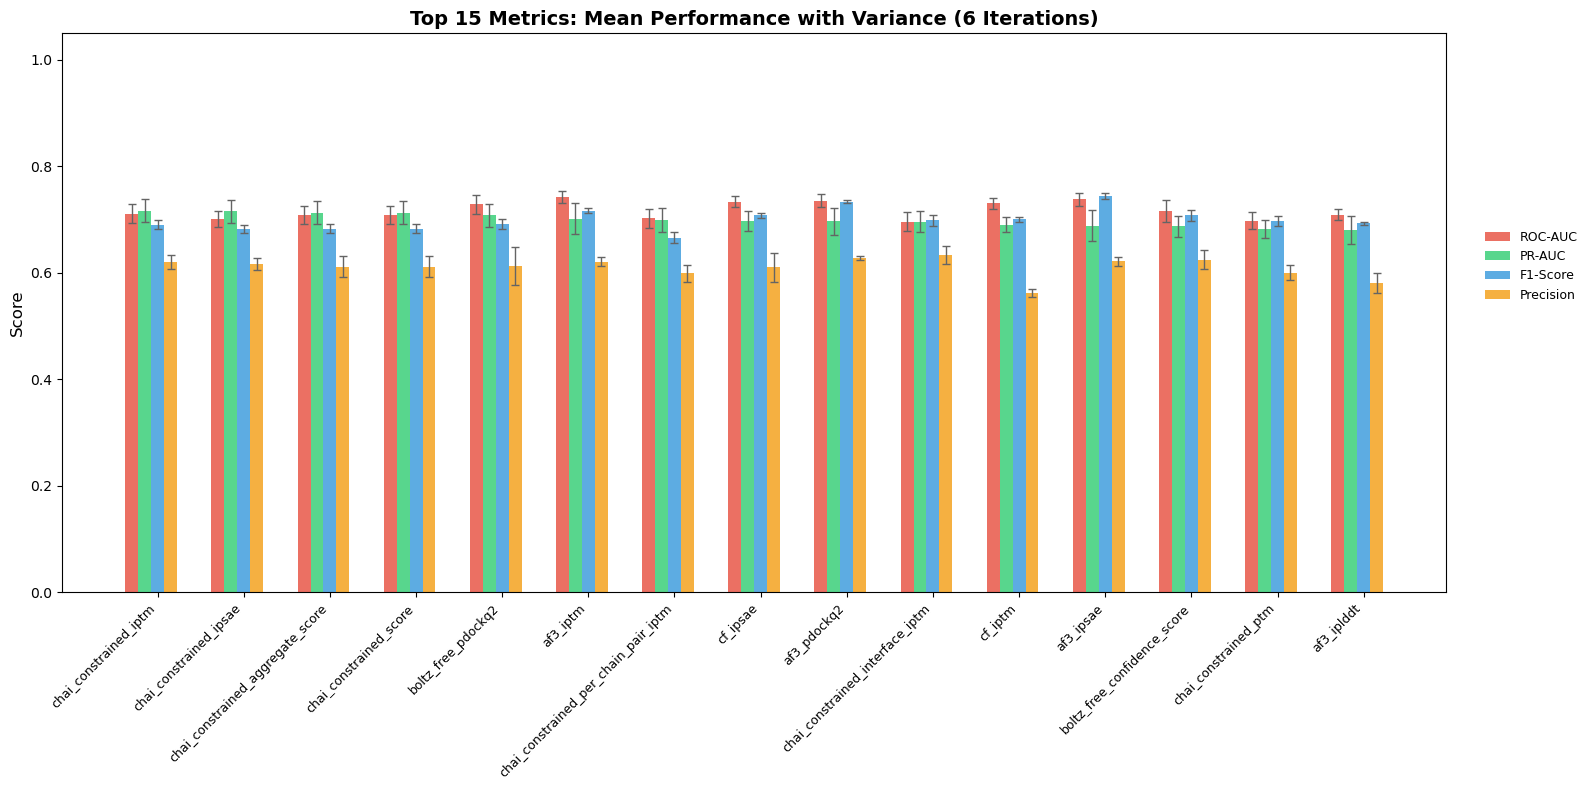

In [28]:
import matplotlib.pyplot as plt

# top 15 based on the mean PR-AUC
top_15 = stats_df.head(15).copy()

fig, ax = plt.subplots(figsize=(16, 8))
x_pos = range(len(top_15))
width = 0.15

metrics_to_plot = [
    ('aligned_roc', 'ROC-AUC', '#e74c3c'),
    ('pr_auc', 'PR-AUC', '#2ecc71'),
    ('f1', 'F1-Score', '#3498db'),
    ('precision', 'Precision', '#f39c12'),
    #('recall', 'Recall', '#9b59b6')
]

# plot each metric with its error bars
for i, (col, label, color) in enumerate(metrics_to_plot):
    # Calculate offset for grouped bar
    offset = (i - 2) * width 
    
    ax.bar(
        [p + offset for p in x_pos], 
        top_15[f'{col}_mean'], 
        width, 
        yerr=top_15[f'{col}_std'], # var
        label=label, 
        color=color, 
        alpha=0.8,
        capsize=3,
        error_kw={'elinewidth': 1, 'ecolor': "#646464"}
    )

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Top 15 Metrics: Mean Performance with Variance (6 Iterations)', 
             fontsize=14, fontweight='bold')

ax.set_xticks(x_pos)
ax.set_xticklabels(top_15['metric'], rotation=45, ha='right', fontsize=9)

# Place legend outside to the right
ax.legend(fontsize=9, loc='lower left', bbox_to_anchor=(1.02, 0.5), frameon=False)

ax.set_ylim([0, 1.05]) # room for error bars
ax.grid(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'top15_metrics_variance.png', dpi=150, bbox_inches='tight')
plt.show()

#### Visualizations

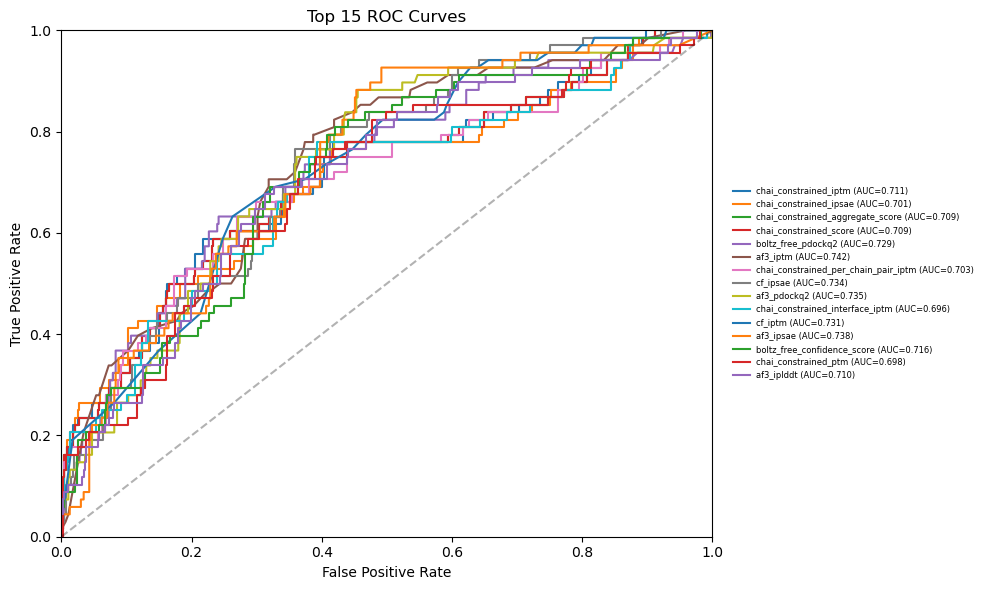

In [29]:
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(10, 6))

for _, row in top_15.iterrows():
    metric = row['metric']
    aligned_roc = row['aligned_roc_mean']
    direction = row['direction_mean']
    
    y_true = df['binder'].values
    clean_idx = df[metric].notna()
    
    y_score = df.loc[clean_idx, metric].values * direction
    y_true_clean = y_true[clean_idx]
    
    fpr, tpr, _ = roc_curve(y_true_clean, y_score)
    
    ax.plot(fpr, tpr, linewidth=1.5, label=f'{metric} (AUC={aligned_roc:.3f})')

# diagonal reference
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Top 15 ROC Curves')

ax.legend(fontsize=6, loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)

ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.grid(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'roc_curves_combined.png', dpi=150, bbox_inches='tight')
plt.show()

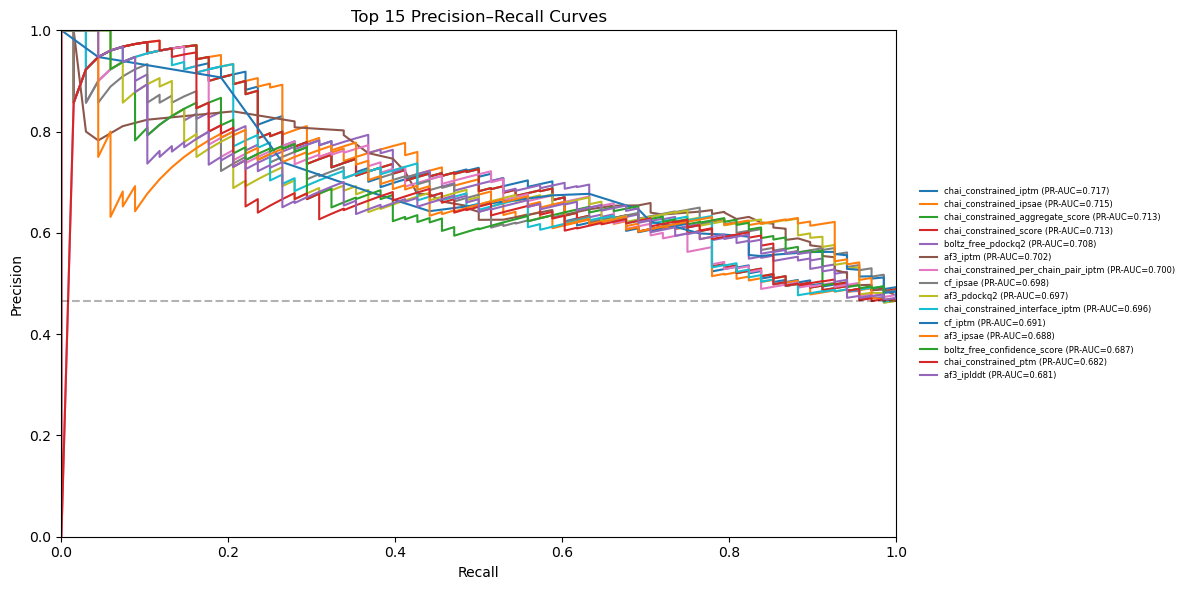

In [30]:
from sklearn.metrics import precision_recall_curve
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))


for i, (_, row) in enumerate(top_15.iterrows()):
    metric = row['metric']
    pr_auc_value = row['pr_auc_mean']
    
    y_true = df['binder'].values
    clean_idx = df[metric].notna()
    
    y_score = df.loc[clean_idx, metric].values
    y_true_clean = y_true[clean_idx]
    
    # skip invalid cases
    if len(np.unique(y_true_clean)) < 2:
        continue
    
    precision, recall, _ = precision_recall_curve(y_true_clean, y_score)

    
    ax.plot(recall, precision, label=f'{metric} (PR-AUC={pr_auc_value:.3f})')

# baseline (positive class prevalence)
baseline = y_true.mean()
ax.hlines(baseline, 0, 1, colors='k', linestyles='--', alpha=0.3)

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Top 15 Precision–Recall Curves')

ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.grid(False)


ax.legend(
    fontsize=6,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'pr_curves_combined.png', dpi=150, bbox_inches='tight')
plt.show()


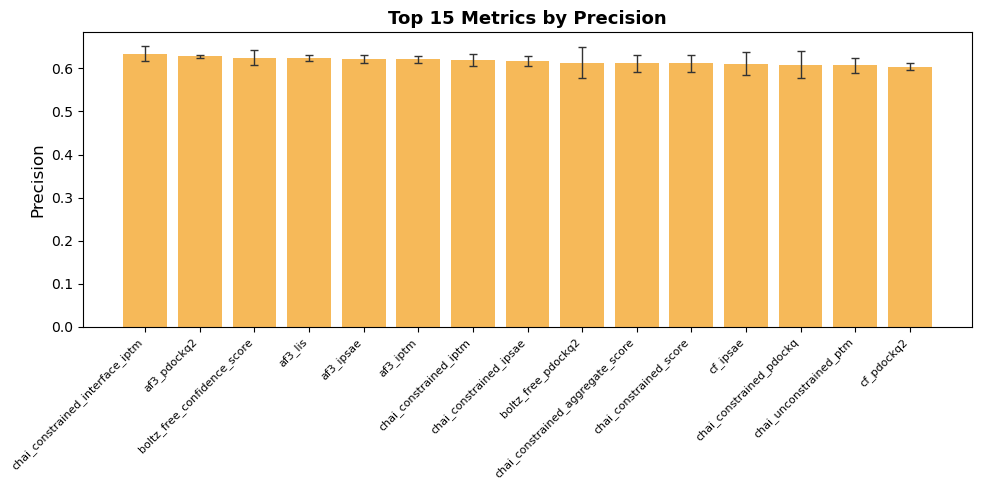

In [31]:
# rearrange rankings by precision
sorted_precision = stats_df.sort_values(
    'precision_mean',
    ascending=False
)

# display labels
"""metric_label_map = {
    "chai_unconstrained_per_chain_iptm": "Chai-1 Interface pTM",
    "cf_ipsae": "ColabFold ipSAE",
    "cf_pdockq2": "ColabFold pDockQ2",
    "cf_iplddt": "ColabFold ipLDDT",
    "af3_ptm": "AF3 pTM",
    "cf_interface_dG": "ColabFold Interface ΔG",
    "af3_ipsae": "AF3 ipSAE",
    "af3_iptm": "AF3 ipTM",
    "esmfold_ipae": "ESMFold ipAE",
    "chai_unconstrained_per_chain_ptm": "Chai-1 pTM",
    "af3_pdockq2": "AF3 pDockQ2",
    "esmfold_iplddt": "ESMFold ipLDDT",
    "boltz_free_ipsae": "Boltz-2 ipSAE",
    "boltz_template_per_chain_pair_iptm": "Boltz-1 Interface pTM",
    "chai_unconstrained_ptm": "Chai-1 pTM",

}"""

# plot top15 precision
fig, ax = plt.subplots(figsize=(10, 5))

top_15_precision = sorted_precision.head(15)

x = np.arange(len(top_15_precision))

ax.bar(
    x,
    top_15_precision['precision_mean'],
    color='#f39c12',
    alpha=0.7,
    yerr=top_15_precision['precision_std'],
    capsize=3,
    error_kw={
        'elinewidth': 1,
        'ecolor': '#333333'
    }
)

ax.set_ylabel('Precision', fontsize=12)
ax.set_title(
    'Top 15 Metrics by Precision',
    fontsize=13,
    fontweight='bold'
)



ax.set_xticks(range(len(top_15_precision)))

ax.set_xticklabels(
    top_15_precision['metric'],
    rotation=45,
    ha='right',
    fontsize=8
)

ax.grid(False)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / 'top15_precision.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

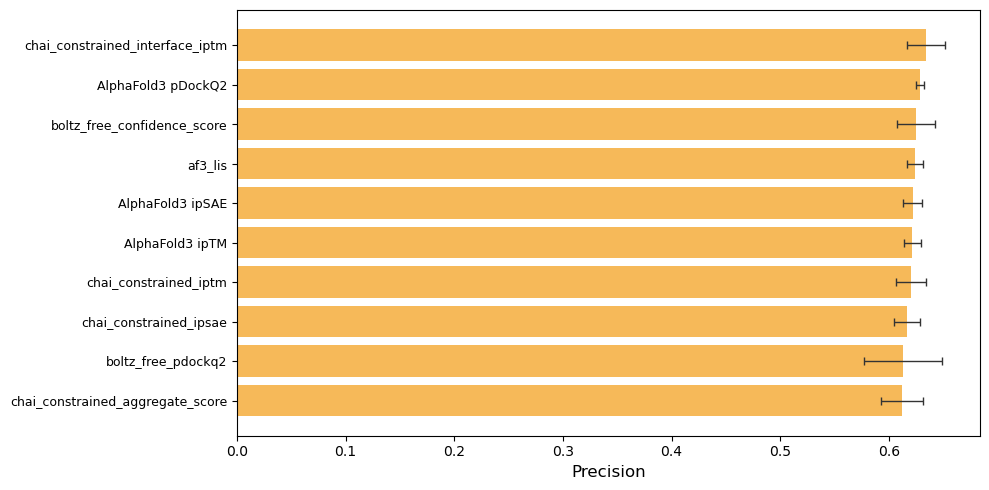

In [32]:
# rearrange rankings by precision
sorted_precision = stats_df.sort_values(
    'precision_mean',
    ascending=False
)

# display labels
metric_label_map = {
    "chai_unconstrained_per_chain_iptm": "Chai-1 ipTM",
    "cf_ipsae": "ColabFold ipSAE",
    "cf_pdockq2": "ColabFold pDockQ2",
    "cf_iplddt": "ColabFold ipLDDT",
    "af3_ptm": "AlphaFold3 pTM",
    "cf_interface_dG": "ColabFold Interface ΔG",
    "af3_ipsae": "AlphaFold3 ipSAE",
    "af3_iptm": "AlphaFold3 ipTM",
    "esmfold_ipae": "ESMFold ipAE",
    "chai_unconstrained_per_chain_ptm": "Chai-1 pTM",
    "af3_pdockq2": "AlphaFold3 pDockQ2",
    "esmfold_iplddt": "ESMFold ipLDDT",
    "boltz_free_ipsae": "Boltz-2 ipSAE",
    "boltz_template_per_chain_pair_iptm": "Boltz-1 ipTM",
    "chai_unconstrained_ptm": "Chai-1 pTM",

}

# plot top15 precision
fig, ax = plt.subplots(figsize=(10, 5))

top_15_precision = sorted_precision.head(10)

# positions
y = np.arange(len(top_15_precision))

# custom labels
display_labels = [
    metric_label_map.get(m, m)
    for m in top_15_precision['metric']
]

# horizontal bars
ax.barh(
    y,
    top_15_precision['precision_mean'],
    color='#f39c12',
    alpha=0.7,
    xerr=top_15_precision['precision_std'],
    capsize=3,
    error_kw={
        'elinewidth': 1,
        'ecolor': '#333333'
    }
)

# y-axis labels
ax.set_yticks(y)
ax.set_yticklabels(display_labels, fontsize=9)

# labels/title
ax.set_xlabel('Precision', fontsize=12)
#ax.set_title('Top 15 Metrics by Precision',fontsize=13,fontweight='bold')

# highest score on top
ax.invert_yaxis()

ax.grid(False)

plt.tight_layout()

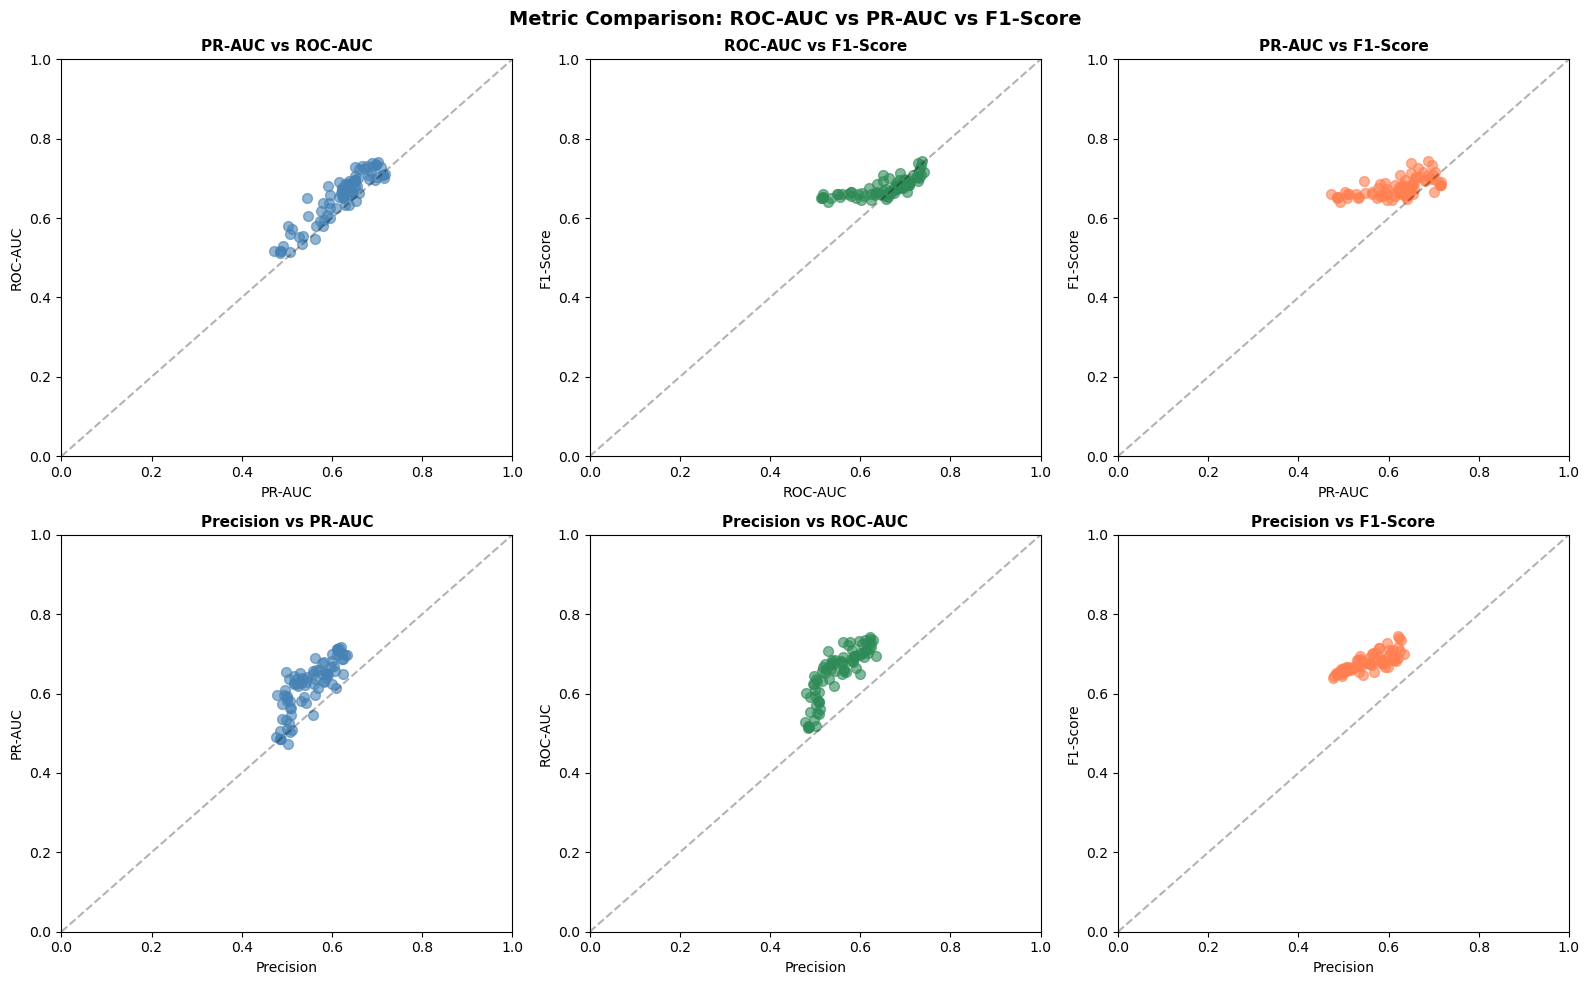

In [33]:
## Compare All Metrics: ROC-AUC, PR-AUC, and F1
sorted_precision = stats_df.sort_values('precision_mean', ascending=False)
sorted_f1 = stats_df.sort_values('f1_mean', ascending=False)
sorted_auc = stats_df.sort_values('aligned_roc_mean', ascending=False)
sorted_pr_auc = stats_df.sort_values('pr_auc_mean', ascending=False)
sorted_recall = stats_df.sort_values('recall_mean', ascending=False)

# Create comprehensive comparison dataframes
comparision = pd.DataFrame({
    'ROC-AUC': sorted_auc['aligned_roc_mean'],
    'PR-AUC': sorted_pr_auc['pr_auc_mean'],
    'F1-Score': sorted_f1['f1_mean'],
    'Precision': sorted_precision['precision_mean'],
    'Recall': sorted_recall['recall_mean']
}).fillna(0).sort_values('PR-AUC', ascending=False)

#print(comparision.to_string())


# Create comprehensive comparison plots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# ROC-AUC vs PR-AUC
ax = axes[0, 0]
ax.scatter(comparision['PR-AUC'], comparision['ROC-AUC'], alpha=0.6, s=50, color='steelblue')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('PR-AUC', fontsize=10)
ax.set_ylabel('ROC-AUC', fontsize=10)
ax.set_title('PR-AUC vs ROC-AUC', fontsize=11, fontweight='bold')
ax.grid(False)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# ROC-AUC vs F1
ax = axes[0, 1]
ax.scatter(comparision['ROC-AUC'], comparision['F1-Score'], alpha=0.6, s=50, color='seagreen')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('ROC-AUC', fontsize=10)
ax.set_ylabel('F1-Score', fontsize=10)
ax.set_title('ROC-AUC vs F1-Score', fontsize=11, fontweight='bold')
ax.grid(False)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# PR-AUC vs F1
ax = axes[0, 2]
ax.scatter(comparision['PR-AUC'], comparision['F1-Score'], alpha=0.6, s=50, color='coral')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('PR-AUC', fontsize=10)
ax.set_ylabel('F1-Score', fontsize=10)
ax.set_title('PR-AUC vs F1-Score', fontsize=11, fontweight='bold')
ax.grid(False)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# Precision vs PR-AUC
ax = axes[1, 0]
ax.scatter(comparision['Precision'], comparision['PR-AUC'], alpha=0.6, s=50, color='steelblue')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('Precision', fontsize=10)
ax.set_ylabel('PR-AUC', fontsize=10)
ax.set_title('Precision vs PR-AUC', fontsize=11, fontweight='bold')
ax.grid(False)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# Precision vsROC-AUC 
ax = axes[1, 1]
ax.scatter(comparision['Precision'], comparision['ROC-AUC'], alpha=0.6, s=50, color='seagreen')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('Precision', fontsize=10)
ax.set_ylabel('ROC-AUC', fontsize=10)
ax.set_title('Precision vs ROC-AUC', fontsize=11, fontweight='bold')
ax.grid(False)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# Precision vs F1
ax = axes[1, 2]
ax.scatter(comparision['Precision'], comparision['F1-Score'], alpha=0.6, s=50, color='coral')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('Precision', fontsize=10)
ax.set_ylabel('F1-Score', fontsize=10)
ax.set_title('Precision vs F1-Score', fontsize=11, fontweight='bold')
ax.grid(False)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])



plt.suptitle('Metric Comparison: ROC-AUC vs PR-AUC vs F1-Score', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'metrics_comparison_combined.png', dpi=150, bbox_inches='tight')
plt.show()

#### Quadrant plots

In [34]:
colors_map = {
    'germinal': "#2ecc71",
    'mcmahon': "#d6a439",
    'snir_ab': "#1f3397",
    'harvey': "#e73cd0"
}

marker_map = {0: "X", 1: "o"}
alpha_map = {"target_shuffle": 0.4, "original": 1.0, "alanine_scan": 1.0}

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

def plot_top_quadrant(scores_df, stats_df, label_points=False):
    # Get Top 2 by PR-AUC
    top_20 = stats_df.sort_values(by='pr_auc_mean', ascending=False).head(20)
    if len(top_20) < 2: return
    
    # Selecting by index
    m1_info, m2_info = top_20.iloc[0], top_20.iloc[2]
    
    m1, t1, d1 = m1_info['metric'], m1_info['opt_threshold_mean'], m1_info['direction_mean']
    m2, t2, d2 = m2_info['metric'], m2_info['opt_threshold_mean'], m2_info['direction_mean']

    # AGGREGATE: Instead of plotting every iteration, plot the MEAN of each sample
    plot_df = scores_df.groupby(['source', 'sample', 'type', 'binder'])[[m1, m2]].agg(['mean', 'std']).reset_index()
    
    # Flatten multi-index columns: 'metric_mean', 'metric_std'
    plot_df.columns = [f"{c[0]}_{c[1]}" if c[1] else c[0] for c in plot_df.columns]

    # Map alpha values directly into the dataframe
    alpha_dict = {"target_shuffle": 0.4, "original": 1.0, "alanine_scan": 1.0}
    plot_df["alpha"] = plot_df["type"].map(alpha_dict)

    plot_df.to_csv(OUTPUT_DIR / 'plot_df.csv', index=False) 

    fig, ax = plt.subplots(figsize=(8, 8))


    # 3. PLOT (Turn legend OFF to prevent column names from appearing)
    for t, subdf in plot_df.groupby("type"):
        sns.scatterplot(
            data=subdf,
            x=f"{m1}_mean", y=f"{m2}_mean",
            hue='source', palette=colors_map,
            style='binder', markers=marker_map,
            s=100, alpha=alpha_map.get(t, 1.0),
            edgecolor='w', legend=False # <--- CRITICAL
        )

    ax.set_aspect("equal", adjustable="box")
    # 4. MANUAL AXIS LABELS (This fixes the "whole column name" issue)
    plt.xlabel(f"{m1}\n(PR-AUC: {m1_info['pr_auc_mean']:.3f})", fontsize=11)
    plt.ylabel(f"{m2}\n(PR-AUC: {m2_info['pr_auc_mean']:.3f})", fontsize=11)
    plt.title(f"Comparing Metrics: {m1} vs {m2}\n", fontsize=14, fontweight='bold')

    # 5. BUILD CUSTOM LEGEND
    legend_handles = []
    
    # Section: Source
    legend_handles.append(mpatches.Patch(color='none', label='SOURCE'))
    for label, color in colors_map.items():
        legend_handles.append(mlines.Line2D([], [], color=color, marker='s', linestyle='None', markersize=8, label=label))

    # Section: Binder
    #legend_handles.append(mpatches.Patch(color='none', label='BINDER'))
    #for val, marker in marker_map.items():
        #legend_handles.append(mlines.Line2D([], [], color='gray', marker=marker, linestyle='None', markersize=8, label=f"Binder: {val}"))

    # Section: Type
    #legend_handles.append(mpatches.Patch(color='none', label='TYPE'))
    #for label, alpha in alpha_map.items():
        #legend_handles.append(mlines.Line2D([], [], color='gray', marker='o', linestyle='None', markersize=8, alpha=alpha, label=label))

    # Thresholds (add to legend too if you like)
    t1_line = plt.axvline(t1, color='black', linestyle='--', alpha=0.3)
    t2_line = plt.axhline(t2, color='black', linestyle='--', alpha=0.3)
    #legend_handles.extend([t1_line, t2_line])

    plt.legend(handles=legend_handles, fontsize=9, loc='lower center', bbox_to_anchor=(1.22, 0.5), frameon=False)
    plt.tight_layout()
    plt.show()

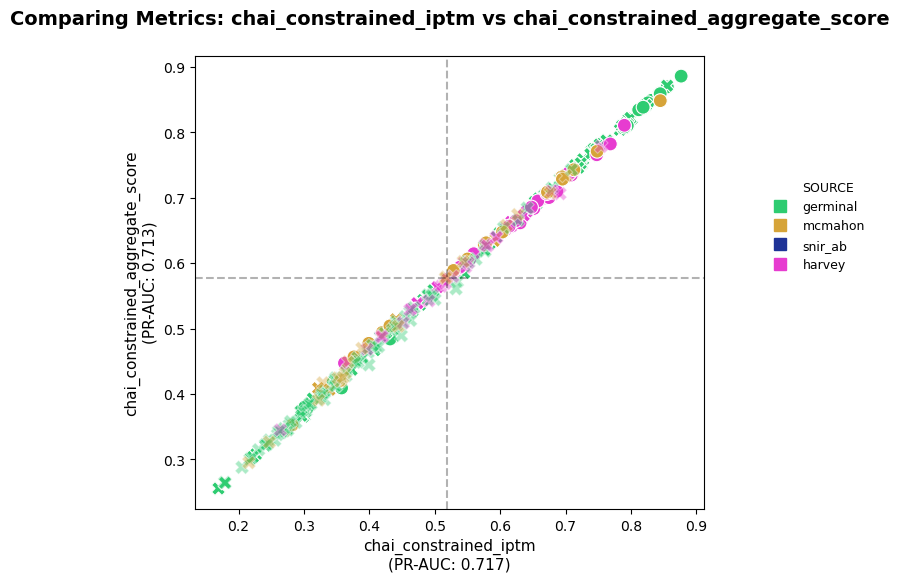

In [36]:
plot_top_quadrant(df, stats_df)

In [37]:
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


def plot_top_quadrant(scores_df, stats_df, label_points=False):
    # Get Top 2 by PR-AUC
    top_20 = stats_df.sort_values(by="pr_auc_mean", ascending=False).head(20)
    if len(top_20) < 2:
        return

    # Selecting by index
    m1_info, m2_info = top_20.iloc[0], top_20.iloc[1]

    m1, t1, d1 = (
        m1_info["metric"],
        m1_info["opt_threshold_mean"],
        m1_info["direction_mean"],
    )
    m2, t2, d2 = (
        m2_info["metric"],
        m2_info["opt_threshold_mean"],
        m2_info["direction_mean"],
    )

    # AGGREGATE
    plot_df = (
        scores_df.groupby(["source", "sample", "type", "binder"])[[m1, m2]]
        .agg(["mean", "std"])
        .reset_index()
    )
    plot_df.columns = [
        f"{c[0]}_{c[1]}" if c[1] else c[0] for c in plot_df.columns
    ]

    # --- LAYOUT FIX 1: Increase width to accommodate the external legend ---
    fig, ax = plt.subplots(figsize=(8, 8))


    # PLOT
    for t, subdf in plot_df.groupby("type"):
        sns.scatterplot(
            data=subdf,
            x=f"{m1}_mean",
            y=f"{m2}_mean",
            hue="source",
            palette=colors_map,
            style="binder",
            markers=marker_map,
            s=80,  # Slightly scaled down for visual clarity
            alpha=alpha_map.get(t, 1.0),
            edgecolor="w",
            linewidth=0.6,
            legend=False,
            ax=ax,
        )

    # --- LAYOUT FIX 2: Explicitly force 1:1 data aspect ratio inside the box ---
    ax.set_aspect("equal", adjustable="box")

    # Threshold lines
    ax.axvline(t1, color="black", linestyle="--", alpha=0.3, zorder=1)
    ax.axhline(t2, color="black", linestyle="--", alpha=0.3, zorder=1)

    # Dynamic limits so points aren't cut off at the edges
    all_x = plot_df[f"{m1}_mean"]
    all_y = plot_df[f"{m2}_mean"]
    min_val = min(all_x.min(), all_y.min()) * 0.9
    max_val = max(all_x.max(), all_y.max()) * 1.05
    ax.set_xlim(0, max_val)
    ax.set_ylim(0, max_val)

    # AXIS LABELS (Added padding)
    ax.set_xlabel(
        f"{m1}\n(PR-AUC: {m1_info['pr_auc_mean']:.3f})",
        fontsize=11,
        labelpad=10,
    )
    ax.set_ylabel(
        f"{m2}\n(PR-AUC: {m2_info['pr_auc_mean']:.3f})",
        fontsize=11,
        labelpad=10,
    )

    legend_name_map = {
    "germinal": "Germinal",
    "mcmahon": "McMahon",
    "snir_ab": "Snir"
}

    # --- LAYOUT FIX 3: Figure level title with padding to stop label overlaps ---
    #fig.suptitle( f"Comparing Metrics: {m1} vs {m2}", fontsize=13, fontweight="bold")
    legend_handles = []
    legend_handles.append(mpatches.Patch(color='none', label='Source'))
    for label, color in colors_map.items():
        legend_handles.append(
            mlines.Line2D(
                [],
                [],
                color=color,
                marker="s",
                linestyle="None",
                markersize=8,
                label=legend_name_map.get(label, label),  # <- rename here
            )
        )

    # --- LAYOUT FIX 4: Moved legend anchor point and cleaned styling ---
    ax.legend(
        handles=legend_handles,
        fontsize=9,
        loc="upper left",
        bbox_to_anchor=(1.05, 0.7),
        frameon=False,
        title_fontproperties={"weight": "bold"},
    )

    # --- LAYOUT FIX 5: Clean padding boundaries manually ---
    plt.tight_layout()
    fig.subplots_adjust(
        top=0.90, right=0.78
    )  # Locks down specific room on the right for the legend
    plt.show()

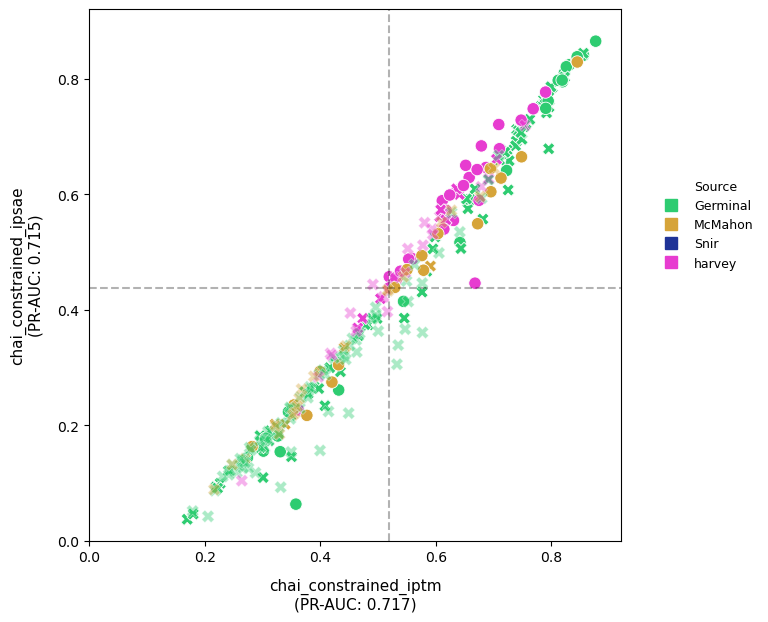

In [38]:
plot_top_quadrant(df, stats_df)

In [39]:
import plotly.graph_objects as go


top_20 = stats_df.sort_values(by='pr_auc_mean', ascending=False).head(20)

m1_info, m2_info = top_20.iloc[0], top_20.iloc[2]

m1, t1, d1 = m1_info['metric'], m1_info['opt_threshold_mean'], m1_info['direction_mean']
m2, t2, d2 = m2_info['metric'], m2_info['opt_threshold_mean'], m2_info['direction_mean']

plot_df = (
    df
    .groupby(['source', 'sample', 'type', 'binder'])[[m1, m2]]
    .agg(['mean', 'std'])
    .reset_index()
)

plot_df.columns = [
    f"{c[0]}_{c[1]}" if c[1] else c[0]
    for c in plot_df.columns
]



# figure setup

fig = go.Figure()

# loop by type so opacity is consistent
for t, type_df in plot_df.groupby("type"):

    opacity = alpha_map.get(t, 1.0)

    # then split by source + binder
    for (source, binder), subdf in type_df.groupby(["source", "binder"]):

        fig.add_trace(
            go.Scatter(
                x=subdf[f"{m1}_mean"],
                y=subdf[f"{m2}_mean"],

                mode='markers',
                
                marker=dict(
                    color=colors_map[source],
                    symbol=marker_map[binder],
                    size=8,
                    opacity=opacity,
                    line=dict(width=0)
                ),

                name=f"{source} | {t} | binder={binder}",

                text=subdf["sample"],

                hovertemplate=(
                    "<b>%{text}</b><br>"
                    f"{m1}: %{{x:.3f}}<br>"
                    f"{m2}: %{{y:.3f}}<br>"
                    f"source: {source}<br>"
                    f"type: {t}<br>"
                    f"binder: {binder}<br>"
                    "<extra></extra>"
                ),

                showlegend=True
            )
        )


# Threshold lines
fig.add_vline(
    x=t1,
    line_dash="dash",
    line_color="black",
    opacity=0.3
)

fig.add_hline(
    y=t2,
    line_dash="dash",
    line_color="black",
    opacity=0.3
)


# Layout
fig.update_layout(
    width=900,
    height=700,
    plot_bgcolor='white',
    title=f"Comparing Metrics: {m1} vs {m2}",
    xaxis_title=f"{m1}<br>(PR-AUC: {m1_info['pr_auc_mean']:.3f})",
    yaxis_title=f"{m2}<br>(PR-AUC: {m2_info['pr_auc_mean']:.3f})",
    legend_title="Source / Type / Binder"
)

fig.show()

ValueError: 
    Invalid value of type 'builtins.str' received for the 'symbol' property of scatter.marker
        Received value: 'X'

    The 'symbol' property is an enumeration that may be specified as:
      - One of the following enumeration values:
            [0, '0', 'circle', 100, '100', 'circle-open', 200, '200',
            'circle-dot', 300, '300', 'circle-open-dot', 1, '1',
            'square', 101, '101', 'square-open', 201, '201',
            'square-dot', 301, '301', 'square-open-dot', 2, '2',
            'diamond', 102, '102', 'diamond-open', 202, '202',
            'diamond-dot', 302, '302', 'diamond-open-dot', 3, '3',
            'cross', 103, '103', 'cross-open', 203, '203',
            'cross-dot', 303, '303', 'cross-open-dot', 4, '4', 'x',
            104, '104', 'x-open', 204, '204', 'x-dot', 304, '304',
            'x-open-dot', 5, '5', 'triangle-up', 105, '105',
            'triangle-up-open', 205, '205', 'triangle-up-dot', 305,
            '305', 'triangle-up

In [ ]:
top_20 = stats_df.sort_values(by='pr_auc_mean', ascending=False).head(20)


print(top_20["metric"].tolist())

['chai_constrained_iptm', 'chai_constrained_ipsae', 'chai_constrained_aggregate_score', 'chai_constrained_score', 'boltz_free_pdockq2', 'af3_iptm', 'chai_constrained_per_chain_pair_iptm', 'cf_ipsae', 'af3_pdockq2', 'chai_constrained_interface_iptm', 'cf_iptm', 'af3_ipsae', 'boltz_free_confidence_score', 'chai_constrained_ptm', 'af3_iplddt', 'boltz_free_pdockq', 'cf_pdockq2', 'af3_pdockq', 'cf_iplddt', 'boltz_free_iplddt']


In [ ]:
df.head()

,source,type,binder,KD[M],sample,af3_pae,af3_plddt,af3_interface_dG,af3_interface_dG_SASA_ratio,af3_ipae,...,boltz_template_pdockq,boltz_template_pdockq2,boltz_template_lis,chai_unconstrained_per_chain_ptm,chai_constrained_per_chain_ptm,chai_unconstrained_per_chain_pair_iptm,chai_constrained_per_chain_pair_iptm,EC50[M],binder_type,iteration
0,mcmahon,original,1,4.310000e-07,Nb.b201_HSA_404-609,6.376025,88.098892,14.46,1.51,9.204167,...,0.3654,0.9208,0.4745,0.877342,0.883705,0.158522,0.672600,NaN,Binder,0
1,mcmahon,original,1,4.310000e-07,Nb.b201_HSA_404-601,6.893648,87.943351,19.06,1.99,10.440385,...,0.3059,0.0374,0.0189,0.862398,0.874311,0.126453,0.594245,NaN,Binder,0
2,mcmahon,original,1,4.310000e-07,Nb.b201_HSA_25-609,13.189712,84.282269,154.23,10.06,28.067391,...,0.5921,0.7323,0.5462,0.869838,0.877728,0.213046,0.670695,NaN,Binder,0
3,mcmahon,original,1,2.300000e-06,Nb.AQ100_Adiponectin,12.931578,81.319338,205.51,11.33,5.768421,...,0.2883,0.0783,0.2570,0.877279,0.869125,0.147860,0.231424,NaN,Binder,0
4,mcmahon,original,0,NaN,Nb.AQ101_Adiponectin,13.803496,80.758365,46.76,3.01,13.596875,...,0.1630,0.0450,0.1986,0.871332,0.876463,0.164553,0.314370,NaN,Non-Binder,0


## Mann-Whitney U / AUROC

In [ ]:
from scipy.stats import mannwhitneyu
U, p = mannwhitneyu(pos, neg, alternative='greater')
auroc = U / (len(pos) * len(neg))  # exact equivalence

## Cliff's delta
 — Cliff's delta is preferable ocer Cohens d, metrics are unlikely to be normally distributed (docking scores, energies, etc.). Cohen's d is fine as a secondary check but flag it.

Spearman correlation heatmap, on top 20 metrics (Spearman, not Pearson) before the PCA/UMAP, as a sanity check that your dimensionality reduction is picking up real redundancy structure.

# PCA

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler


df = pd.read_parquet("/home/bri/pymol/EDA/scores_aligned.parquet")

# keep numeric only
X = df.select_dtypes(include=["number"])

# optional: handle inf / NaN
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from umap import UMAP

# --- Data prep ---
X_feat = X.T  # rows = metrics, cols = samples — keep as DataFrame
metric_names = X_feat.index
X_scaled = StandardScaler().fit_transform(X_feat.values)

# --- Strip model prefix ---
models_sorted = sorted(
    ['af3', 'cf', 'esmfold', 'chai_constrained', 'chai_unconstrained',
     'boltz_free', 'boltz_template'],
    key=len, reverse=True
)

def strip_model_prefix(metric_name, models_sorted):
    for model in models_sorted:
        if metric_name.startswith(model + "_"):
            return metric_name[len(model) + 1:]
    return metric_name

metric_types = pd.Series(
    [strip_model_prefix(m, models_sorted) for m in metric_names],
    index=metric_names
)

# --- Color map ---
metric_family_colors = {
    # Confidence / pLDDT family (blues)
    "plddt":                        "tab:blue",
    "iplddt":                       "steelblue",
    "pred_lddt":                    "cornflowerblue",
    "pred_ilddt":                   "royalblue",
    # PTM / iPTM family (cyans)
    "ptm":                          "tab:cyan",
    "iptm":                         "darkcyan",
    "per_chain_ptm":                "mediumturquoise",
    "per_chain_pair_iptm":          "teal",
    "interface_iptm":               "cadetblue",
    # PAE / error estimates (purples)
    "pae":                          "tab:purple",
    "ipae":                         "mediumpurple",
    "ipsae":                        "orchid",
    "pde":                          "rebeccapurple",
    "ipde":                         "blueviolet",
    # Interface energetics (reds)
    "interface_dG":                 "tab:red",
    "interface_dG_SASA_ratio":      "tomato",
    "interface_energy":             "firebrick",
    "dG":                           "tab:orange",
    # Docking scores (greens)
    "docking_score":                "tab:green",
    "pdockq":                       "limegreen",
    "pdockq2":                      "mediumseagreen",
    "score":                        "darkgreen",
    "confidence_score":             "yellowgreen",
    "aggregate_score":              "olivedrab",
    "pyros_binder_score":           "darkolivegreen",
    "binder_score":                 "tab:olive",
    # Structural / shape (pinks/browns)
    "rmsd":                         "tab:pink",
    "af3_rmsd":                     "hotpink",
    "tm_score":                     "tab:brown",
    "clash_score":                  "sienna",
    "lis":                          "rosybrown",
    # Experimental / biological (yellows)
    "EC50[M]":                      "gold",
    "KD[M]":                        "goldenrod",
    "binder":                       "darkgoldenrod",
    # Fallback
    "other":                        "tab:gray",
}

def assign_color(metric_type, color_map):
    if metric_type in color_map:
        return color_map[metric_type]
    for key in sorted(color_map, key=len, reverse=True):
        if metric_type.startswith(key):
            return color_map[key]
    return color_map["other"]

point_colors = metric_types.map(
    lambda t: assign_color(t, metric_family_colors)
).tolist()

# --- Debug ---
print(f"X_feat shape: {X_feat.shape}")
print(f"n metrics:    {len(metric_types)}")
print("\nStripped metric types:")
print(pd.DataFrame({"original": metric_names, "stripped": metric_types.values}).to_string(index=False))
print("\nType counts:")
print(metric_types.value_counts())

# --- Embeddings ---
pca = PCA(n_components=2, random_state=42)
emb_pca = pca.fit_transform(X_scaled)
print(f"\nPC1: {pca.explained_variance_ratio_[0]:.1%}  PC2: {pca.explained_variance_ratio_[1]:.1%}")

emb_umap = UMAP(n_neighbors=10, min_dist=0.1, random_state=42).fit_transform(X_scaled)

# --- Legend handles (shared) ---
present_types = metric_types.unique()
legend_handles = [
    Line2D([0], [0], marker='o', linestyle='', markersize=8,
           color=assign_color(t, metric_family_colors), label=t)
    for t in sorted(present_types)
]

# --- Plot helper ---
def plot_embedding(ax, emb, title, xlabel, ylabel, show_labels=True
    ax.scatter(emb[:, 0], emb[:, 1], c=point_colors, s=60, zorder=2)
    if show_labels:
        for i, name in enumerate(metric_names):
            ax.annotate(name, (emb[i, 0], emb[i, 1]), fontsize=6, alpha=0.75)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

# --- Figure ---
fig, axes = plt.subplots(1, 2, figsize=(22, 10))

plot_embedding(
    axes[0], emb_pca,
    title="PCA of Metrics — Colored by Metric Type\n(model identity stripped)",
    xlabel=f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)",
    ylabel=f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)",
    # show_labels=False
)

plot_embedding(
    axes[1], emb_umap,
    title="UMAP of Metrics — Colored by Metric Type\n(model identity stripped)",
    xlabel="UMAP 1",
    ylabel="UMAP 2",
    # show_labels=False
)

fig.legend(
    handles=legend_handles,
    title="Metric Type",
    bbox_to_anchor=(1.01, 1),
    loc="upper left",
    borderaxespad=0,
)
plt.tight_layout()
plt.show()

SyntaxError: '(' was never closed (2907914870.py, line 116)

X_feat shape: (83, 611)
n metrics:    83

Model assignments:
                                metric              model
                                binder              other
                                 KD[M]              other
                               af3_pae                af3
                             af3_plddt                af3
                      af3_interface_dG                af3
           af3_interface_dG_SASA_ratio                af3
                              af3_ipae                af3
                            af3_iplddt                af3
                             af3_ipsae                af3
                            af3_pdockq                af3
                           af3_pdockq2                af3
                               af3_lis                af3
                              af3_iptm                af3
                               af3_ptm                af3
                af3_pyros_binder_score                af3
           

/home/bri/micromamba/envs/pymol/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


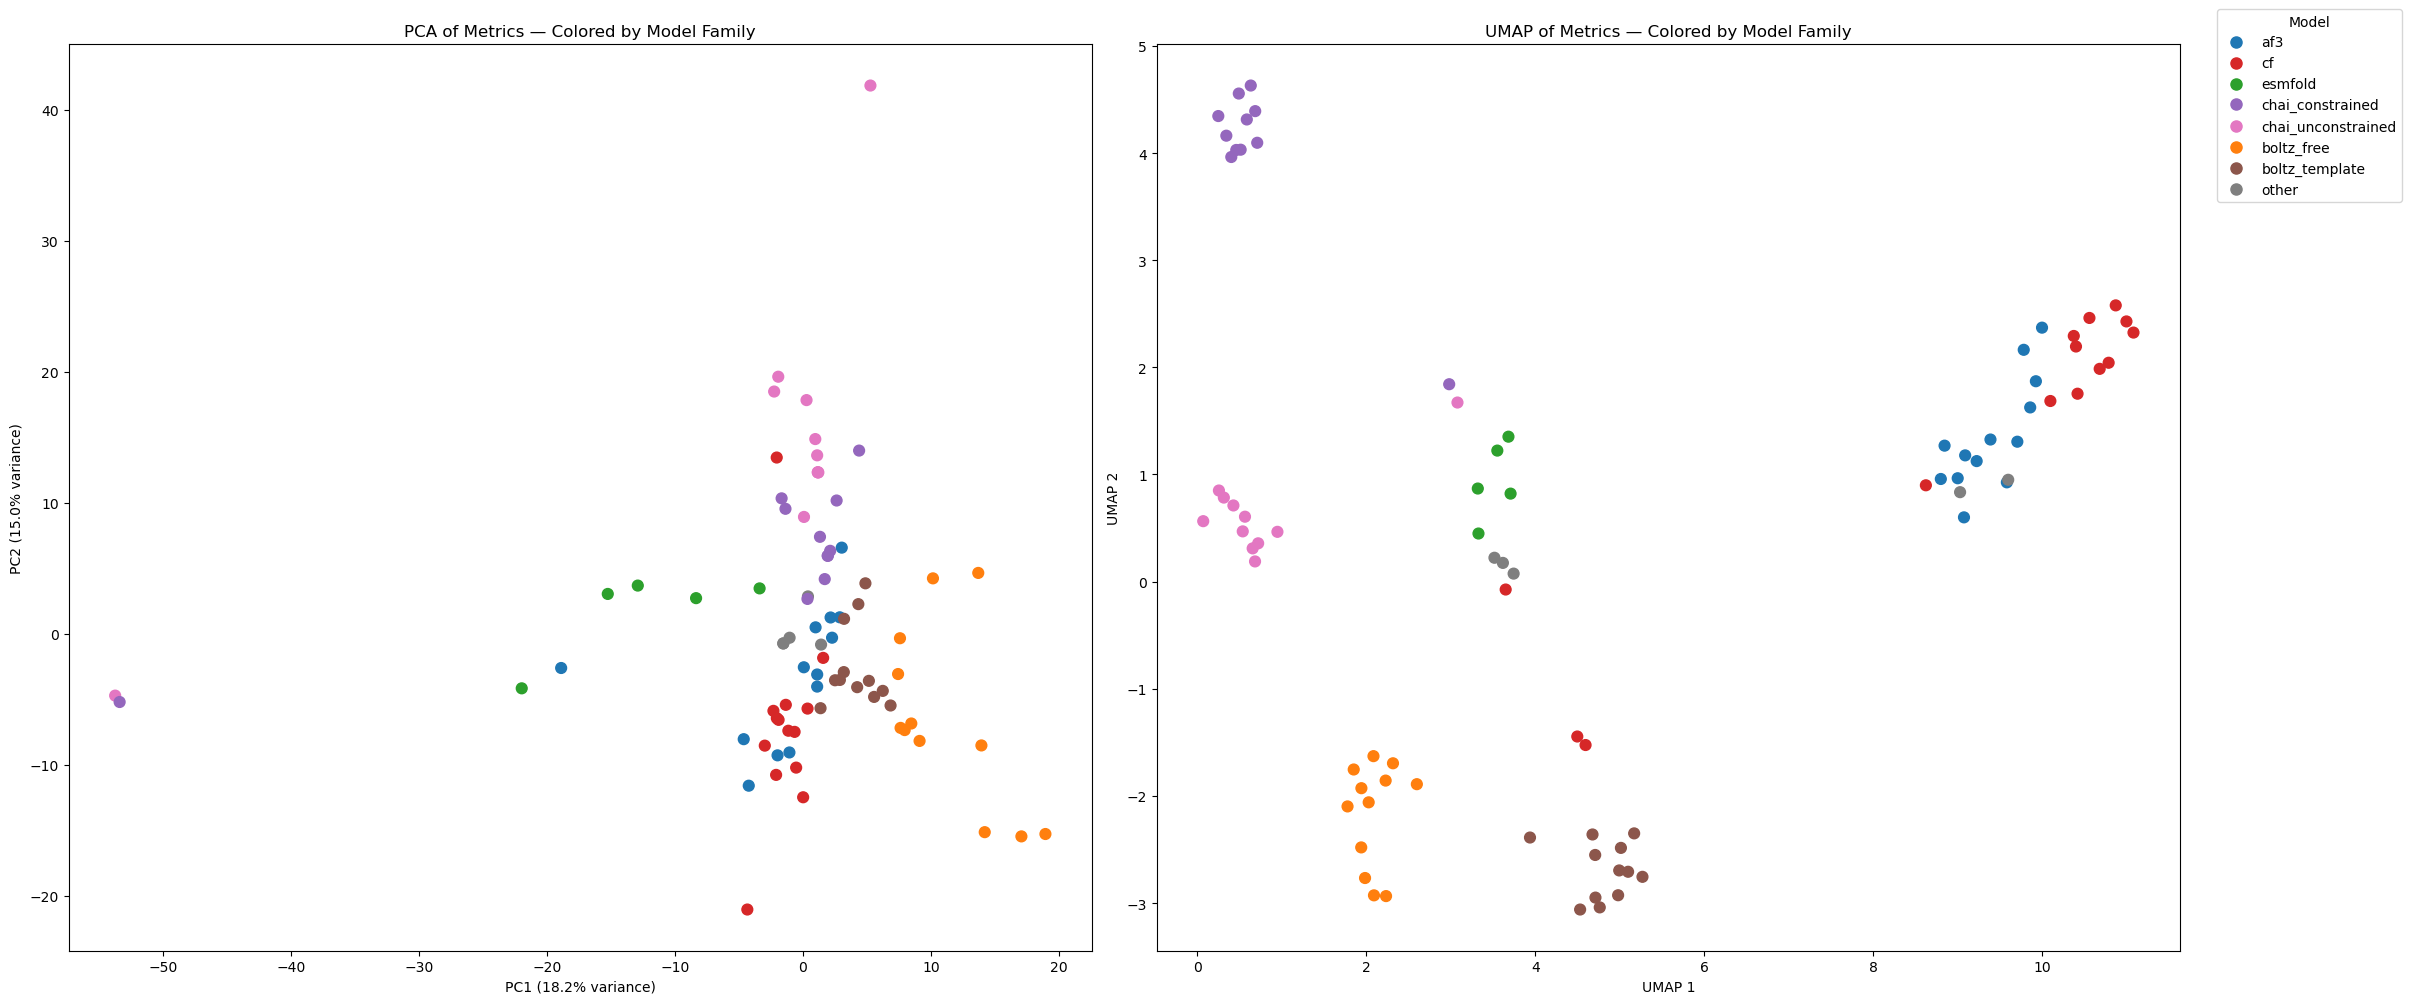

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from umap import UMAP

# --- Data prep ---
X_feat = X.T  # rows = metrics, cols = samples — keep as DataFrame
metric_names = X_feat.index
X_scaled = StandardScaler().fit_transform(X_feat.values)

# --- Model assignment (longest prefix first to avoid shadowing) ---
models = [
    'af3', 'cf', 'esmfold',
    'chai_constrained', 'chai_unconstrained',
    'boltz_free', 'boltz_template', 'other'
]
colors = {
    "af3":                  "tab:blue",
    "cf":                   "tab:red",
    "esmfold":              "tab:green",
    "chai_constrained":     "tab:purple",
    "chai_unconstrained":   "tab:pink",
    "boltz_free":           "tab:orange",
    "boltz_template":       "tab:brown",
    "other":                "tab:gray",
}
models_sorted = sorted([m for m in models if m != "other"], key=len, reverse=True)

metric_models = []
for metric in metric_names:
    assigned = "other"
    for model in models_sorted:
        if metric.startswith(model + "_") or metric == model:
            assigned = model
            break
    metric_models.append(assigned)

metric_models = pd.Series(metric_models, index=metric_names)
point_colors = metric_models.map(colors).tolist()

# --- Debug ---
print(f"X_feat shape: {X_feat.shape}")
print(f"n metrics:    {len(metric_models)}")
print("\nModel assignments:")
print(pd.DataFrame({"metric": metric_names, "model": metric_models.values}).to_string(index=False))
print("\nModel counts:")
print(metric_models.value_counts())

# --- Embeddings ---
pca = PCA(n_components=2, random_state=42)
emb_pca = pca.fit_transform(X_scaled)
print(f"\nPC1: {pca.explained_variance_ratio_[0]:.1%}  PC2: {pca.explained_variance_ratio_[1]:.1%}")

emb_umap = UMAP(n_neighbors=10, min_dist=0.1, random_state=42).fit_transform(X_scaled)

# --- Legend handles (shared) ---
present_models = metric_models.unique()
legend_handles = [
    Line2D([0], [0], marker='o', linestyle='', markersize=8, color=colors[m], label=m)
    for m in models  # explicit order, not alphabetical
    if m in present_models
]

# --- Plot helper ---
def plot_embedding(ax, emb, title, xlabel, ylabel, show_labels=False):
    ax.scatter(emb[:, 0], emb[:, 1], c=point_colors, s=60, zorder=2)
    if show_labels:
        for i, name in enumerate(metric_names):
            ax.annotate(name, (emb[i, 0], emb[i, 1]), fontsize=6, alpha=0.75)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

# --- Figure ---
fig, axes = plt.subplots(1, 2, figsize=(22, 10))

plot_embedding(
    axes[0], emb_pca,
    title="PCA of Metrics — Colored by Model Family",
    xlabel=f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)",
    ylabel=f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)",
    # show_labels=False
)

plot_embedding(
    axes[1], emb_umap,
    title="UMAP of Metrics — Colored by Model Family",
    xlabel="UMAP 1",
    ylabel="UMAP 2",
    # show_labels=Fals
)

fig.legend(
    handles=legend_handles,
    title="Model",
    bbox_to_anchor=(1.01, 1),
    loc="upper left",
    borderaxespad=0,
)
plt.tight_layout()
plt.show()

# UMAP

## models cluster

In [ ]:
X_feat = X.T

from sklearn.preprocessing import StandardScaler
X_scaled = StandardScaler().fit_transform(X_feat)

from umap import UMAP
emb = UMAP(
    n_neighbors=10,
    min_dist=0.1,
    random_state=42
).fit_transform(X_scaled)

/home/bri/micromamba/envs/pymol/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [ ]:
print(X_feat.shape)
print(emb.shape)

(83, 611)
(83, 2)


In [ ]:
print(len(metric_models))
print(len(emb))

83
83


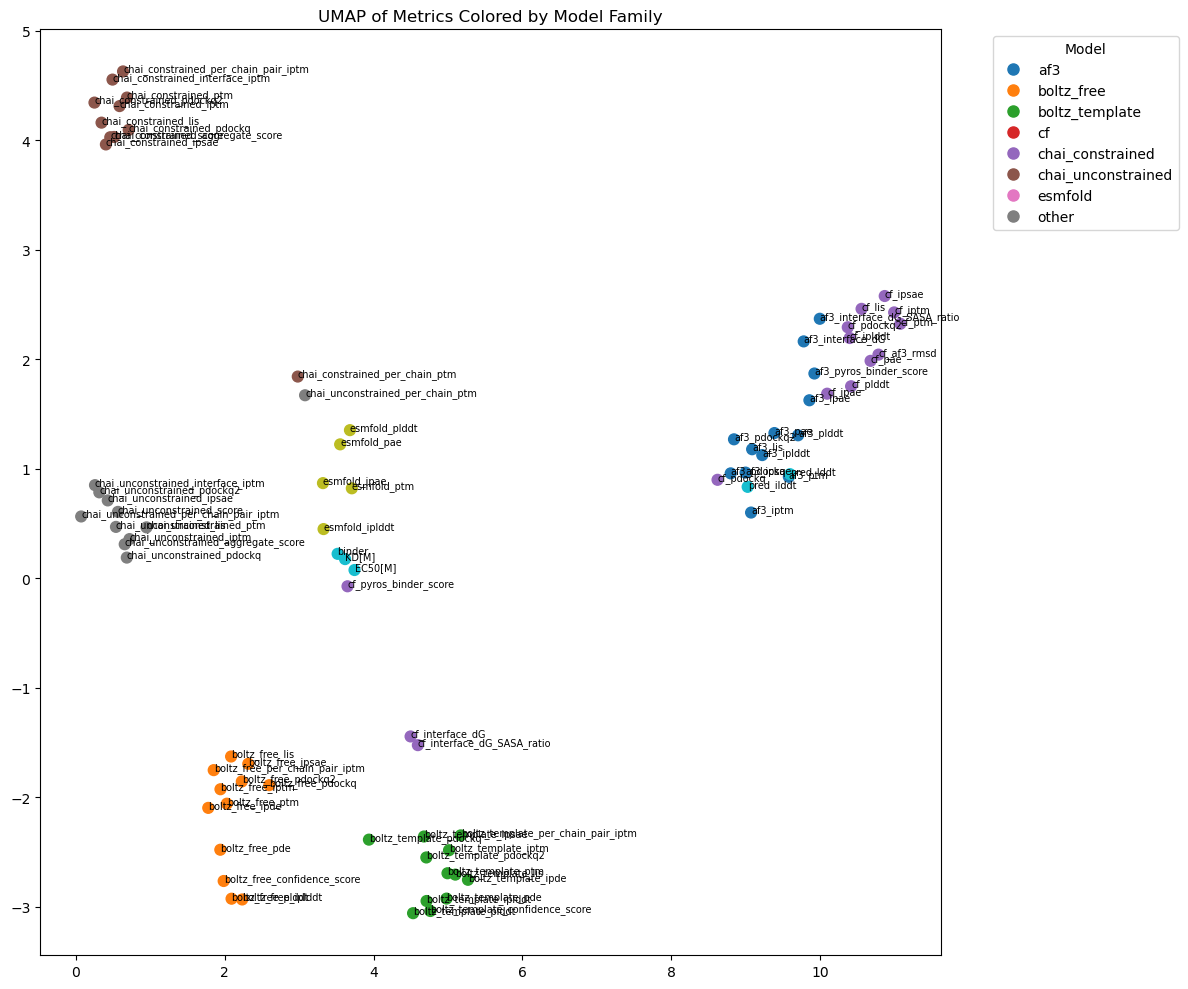

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd

models = [
    'af3',
    'cf',
    'esmfold',
    'chai_constrained',
    'chai_unconstrained',
    'boltz_free',
    'boltz_template',
    'other'
]

colors = {
    "af3": "tab:blue",
    "cf": "tab:red",
    "esmfold": "tab:green",
    "chai_constrained": "tab:purple",
    "chai_unconstrained": "tab:pink",
    "boltz_free": "tab:orange",
    "boltz_template": "tab:brown",
    "other": "tab:gray",
}


# Determine model group for each metric
metric_models = []


for metric in X_feat.index:
    assigned = "other"

    for model in models:
        if metric.startswith(model):
            assigned = model
            break

    metric_models.append(assigned)

metric_models = pd.Series(metric_models, index=X_feat.index)

# Convert model names to color codes
codes = metric_models.astype("category").cat.codes

fig, ax = plt.subplots(figsize=(12, 10))

scatter = ax.scatter(
    emb[:, 0],
    emb[:, 1],
    c=codes,
    cmap="tab10",
    s=60
)

# Metric labels
for i, name in enumerate(X_feat.index):
    ax.text(
        emb[i, 0],
        emb[i, 1],
        name,
        fontsize=7
    )

# Build legend
categories = metric_models.astype("category").cat.categories
cmap = plt.get_cmap("tab10")

legend_handles = [
    Line2D(
        [0], [0],
        marker='o',
        linestyle='',
        markersize=8,
        color=cmap(i),
        label=cat
    )
    for i, cat in enumerate(categories)
]

ax.legend(
    handles=legend_handles,
    title="Model",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

ax.set_title("UMAP of Metrics Colored by Model Family")
plt.tight_layout()
plt.show()

In [ ]:
print(metric_models.value_counts())

cf                    14
af3                   13
boltz_free            12
boltz_template        12
chai_unconstrained    11
chai_constrained      11
other                  5
esmfold                5
Name: count, dtype: int64


## models cluster

/home/bri/micromamba/envs/pymol/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


X_feat shape: (83, 611)
emb shape:    (83, 2)
n metrics:    83
cf                    14
af3                   13
boltz_free            12
boltz_template        12
chai_unconstrained    11
chai_constrained      11
other                  5
esmfold                5
Name: count, dtype: int64


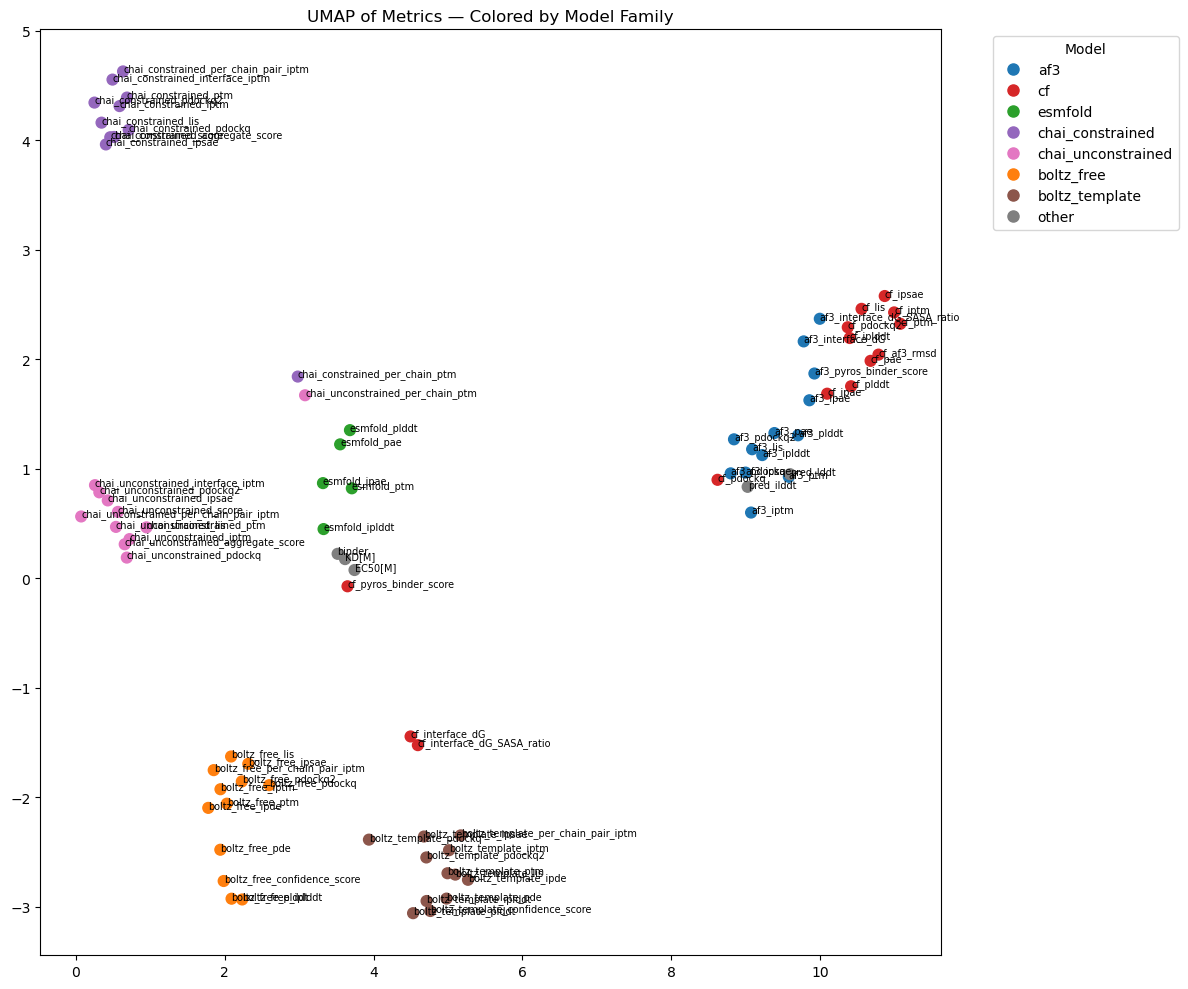

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.preprocessing import StandardScaler
from umap import UMAP

# --- Data prep ---
X_feat = X.T  # rows = metrics, cols = samples — keep as DataFrame
metric_names = X_feat.index

X_scaled = StandardScaler().fit_transform(X_feat.values)

# --- UMAP ---
emb = UMAP(n_neighbors=10, min_dist=0.1, random_state=42).fit_transform(X_scaled)

# --- Model assignment (longest prefix first to avoid shadowing) ---
models = [
    'af3', 'cf', 'esmfold',
    'chai_constrained', 'chai_unconstrained',
    'boltz_free', 'boltz_template', 'other'
]
colors = {
    "af3": "tab:blue", "cf": "tab:red", "esmfold": "tab:green",
    "chai_constrained": "tab:purple", "chai_unconstrained": "tab:pink",
    "boltz_free": "tab:orange", "boltz_template": "tab:brown", "other": "tab:gray",
}
models_sorted = sorted([m for m in models if m != "other"], key=len, reverse=True)

metric_models = []
for metric in metric_names:
    assigned = "other"
    for model in models_sorted:
        if metric.startswith(model + "_") or metric == model:
            assigned = model
            break
    metric_models.append(assigned)

metric_models = pd.Series(metric_models, index=metric_names)

# Debug prints — after metric_models is built
print(f"X_feat shape: {X_feat.shape}")
print(f"emb shape:    {emb.shape}")
print(f"n metrics:    {len(metric_models)}")
print(metric_models.value_counts())

# --- Plot (model space analysis) ---
point_colors = metric_models.map(colors)

fig, ax = plt.subplots(figsize=(12, 10))
ax.scatter(emb[:, 0], emb[:, 1], c=point_colors, s=60, zorder=2)

for i, name in enumerate(metric_names):
    ax.text(emb[i, 0], emb[i, 1], name, fontsize=7)

legend_handles = [
    Line2D([0], [0], marker='o', linestyle='', markersize=8,
           color=colors[m], label=m)
    for m in models  # explicit order, not alphabetical
]
ax.legend(handles=legend_handles, title="Model",
          bbox_to_anchor=(1.05, 1), loc="upper left")
ax.set_title("UMAP of Metrics — Colored by Model Family")
plt.tight_layout()
plt.show()

In [ ]:
X_feat["cluster"] = labels

In [ ]:
cluster_summary = {}

for c in sorted(X_feat["cluster"].unique()):
    if c == -1:
        continue

    members = X_feat[X_feat["cluster"] == c].index.tolist()
    cluster_summary[c] = members

cluster_summary

{np.int64(0): ['chai_unconstrained_score',
  'chai_unconstrained_aggregate_score',
  'chai_unconstrained_ptm',
  'chai_unconstrained_iptm',
  'chai_unconstrained_interface_iptm',
  'chai_unconstrained_ipsae',
  'chai_unconstrained_pdockq',
  'chai_unconstrained_pdockq2',
  'chai_unconstrained_lis',
  'chai_unconstrained_per_chain_pair_iptm'],
 np.int64(1): ['af3_ptm',
  'esmfold_plddt',
  'esmfold_pae',
  'chai_constrained_score',
  'chai_constrained_aggregate_score',
  'chai_constrained_ptm',
  'chai_constrained_iptm',
  'chai_constrained_interface_iptm',
  'chai_constrained_ipsae',
  'chai_constrained_pdockq',
  'chai_constrained_pdockq2',
  'chai_constrained_lis',
  'chai_unconstrained_per_chain_ptm',
  'chai_constrained_per_chain_ptm',
  'chai_constrained_per_chain_pair_iptm'],
 np.int64(2): ['boltz_free_confidence_score',
  'boltz_free_ptm',
  'boltz_free_iptm',
  'boltz_free_plddt',
  'boltz_free_iplddt',
  'boltz_free_pde',
  'boltz_free_ipde',
  'boltz_free_per_chain_pair_iptm'

In [ ]:
def interpret_cluster(metrics):
    metrics = [m.lower() for m in metrics]

    score = {
        "confidence": 0,
        "energy": 0,
        "docking": 0,
        "structure": 0
    }

    for m in metrics:
        # confidence signals
        if any(x in m for x in ["plddt", "ptm", "iptm", "confidence"]):
            score["confidence"] += 1

        # energy / stability signals
        if any(x in m for x in ["dG", "ipae", "ipsae", "energy", "pde"]):
            score["energy"] += 1

        # docking / interface
        if any(x in m for x in ["pdockq", "interface", "lis"]):
            score["docking"] += 1

        # structural agreement
        if any(x in m for x in ["rmsd", "pae", "lddt"]):
            score["structure"] += 1

    return max(score, key=score.get), score

In [ ]:
for c, members in cluster_summary.items():
    label, scores = interpret_cluster(members)

    print(f"\nCluster {c}: {label}")
    print("Metrics:", members)
    print("Scores:", scores)


Cluster 0: confidence
Metrics: ['chai_unconstrained_score', 'chai_unconstrained_aggregate_score', 'chai_unconstrained_ptm', 'chai_unconstrained_iptm', 'chai_unconstrained_interface_iptm', 'chai_unconstrained_ipsae', 'chai_unconstrained_pdockq', 'chai_unconstrained_pdockq2', 'chai_unconstrained_lis', 'chai_unconstrained_per_chain_pair_iptm']
Scores: {'confidence': 4, 'energy': 1, 'docking': 4, 'structure': 0}

Cluster 1: confidence
Metrics: ['af3_ptm', 'esmfold_plddt', 'esmfold_pae', 'chai_constrained_score', 'chai_constrained_aggregate_score', 'chai_constrained_ptm', 'chai_constrained_iptm', 'chai_constrained_interface_iptm', 'chai_constrained_ipsae', 'chai_constrained_pdockq', 'chai_constrained_pdockq2', 'chai_constrained_lis', 'chai_unconstrained_per_chain_ptm', 'chai_constrained_per_chain_ptm', 'chai_constrained_per_chain_pair_iptm']
Scores: {'confidence': 8, 'energy': 1, 'docking': 4, 'structure': 2}

Cluster 2: confidence
Metrics: ['boltz_free_confidence_score', 'boltz_free_ptm',

## metrics cluster

In [ ]:
# Strip model prefix to get metric type
def strip_model_prefix(metric_name, models_sorted):
    for model in models_sorted:
        if metric_name.startswith(model + "_"):
            return metric_name[len(model)+1:]
    return metric_name

metric_types = [strip_model_prefix(m, models_sorted) for m in metric_names]

/home/bri/micromamba/envs/pymol/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


['EC50[M]', 'KD[M]', 'af3_rmsd', 'aggregate_score', 'binder', 'confidence_score', 'interface_dG', 'interface_dG_SASA_ratio', 'interface_iptm', 'ipae', 'ipde', 'iplddt', 'ipsae', 'iptm', 'lis', 'pae', 'pde', 'pdockq', 'pdockq2', 'per_chain_pair_iptm', 'per_chain_ptm', 'plddt', 'pred_ilddt', 'pred_lddt', 'ptm', 'pyros_binder_score', 'score']
X_feat shape: (83, 611)
emb shape:    (83, 2)

Stripped metric types:
                              original                stripped
                                binder                  binder
                                 KD[M]                   KD[M]
                               af3_pae                     pae
                             af3_plddt                   plddt
                      af3_interface_dG            interface_dG
           af3_interface_dG_SASA_ratio interface_dG_SASA_ratio
                              af3_ipae                    ipae
                            af3_iplddt                  iplddt
                     

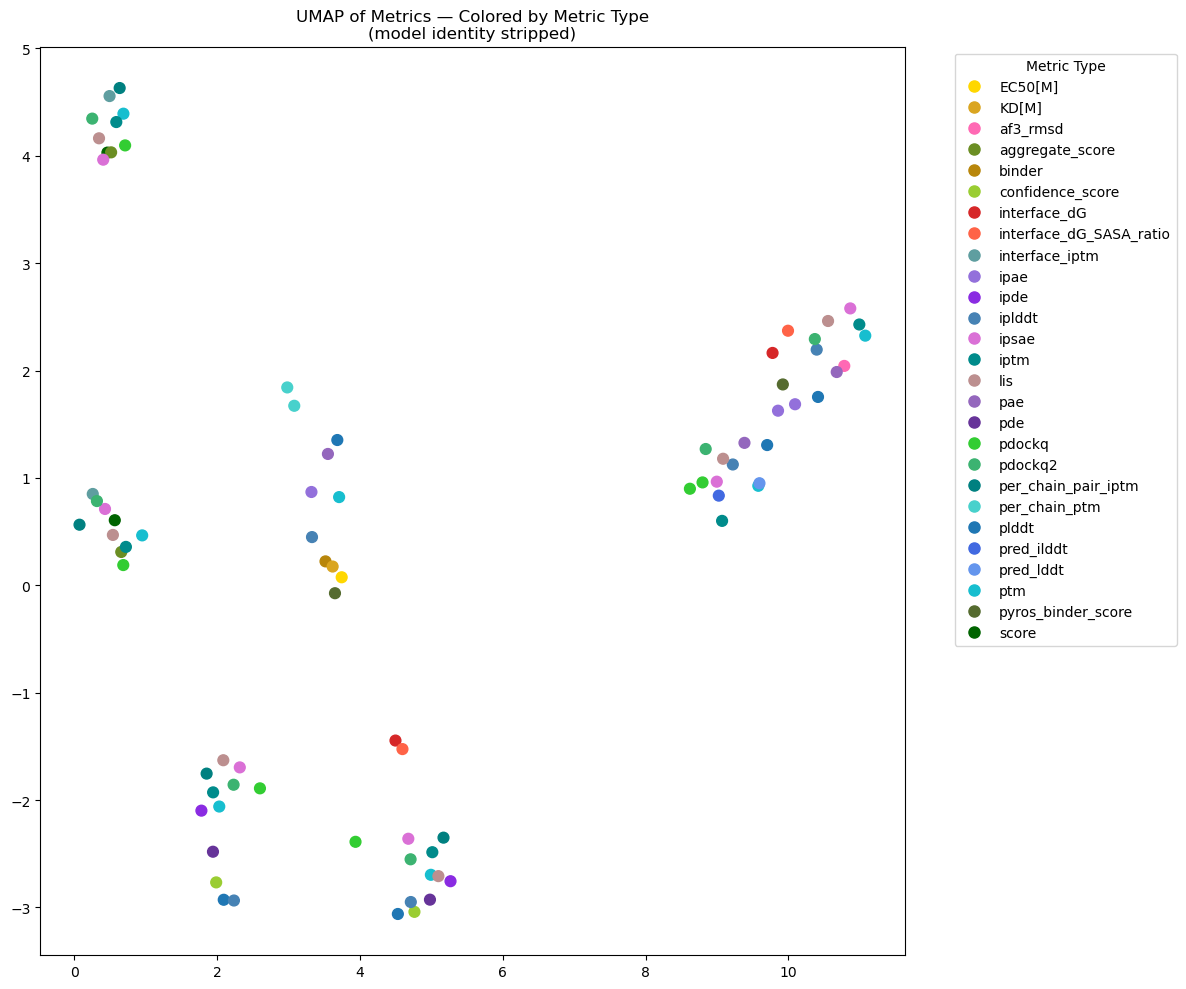

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.preprocessing import StandardScaler
from umap import UMAP

# --- Data prep ---
X_feat = X.T  # rows = metrics, cols = samples — keep as DataFrame
metric_names = X_feat.index

X_scaled = StandardScaler().fit_transform(X_feat.values)

# --- UMAP ---
emb = UMAP(n_neighbors=10, min_dist=0.1, random_state=42).fit_transform(X_scaled)

# --- Strip model prefix to get bare metric type ---
models_sorted = sorted(
    ['af3', 'cf', 'esmfold', 'chai_constrained', 'chai_unconstrained',
     'boltz_free', 'boltz_template'],
    key=len, reverse=True  # longest first to avoid shadowing
)

def strip_model_prefix(metric_name, models_sorted):
    for model in models_sorted:
        if metric_name.startswith(model + "_"):
            return metric_name[len(model) + 1:]
    return metric_name  # no known prefix → keep as-is

metric_types = pd.Series(
    [strip_model_prefix(m, models_sorted) for m in metric_names],
    index=metric_names
)

print(sorted(metric_types.unique()))

# --- Assign colors to metric types ---
# Define known metric families and their colors
metric_family_colors = {
    # --- Confidence / pLDDT family (blues) ---
    "plddt":                        "tab:blue",
    "iplddt":                       "steelblue",
    "pred_lddt":                    "cornflowerblue",
    "pred_ilddt":                   "royalblue",

    # --- PTM / iPTM family (cyans) ---
    "ptm":                          "tab:cyan",
    "iptm":                         "darkcyan",
    "per_chain_ptm":                "mediumturquoise",
    "per_chain_pair_iptm":          "teal",
    "interface_iptm":               "cadetblue",

    # --- PAE / error estimates (purples) ---
    "pae":                          "tab:purple",
    "ipae":                         "mediumpurple",
    "ipsae":                        "plum",
    "ipsae":                        "orchid",
    "pde":                          "rebeccapurple",
    "ipde":                         "blueviolet",

    # --- Interface energetics (reds) ---
    "interface_dG":                 "tab:red",
    "interface_dG_SASA_ratio":      "tomato",
    "interface_energy":             "firebrick",
    "dG":                           "tab:orange",

    # --- Docking scores (greens) ---
    "docking_score":                "tab:green",
    "pdockq":                       "limegreen",
    "pdockq2":                      "mediumseagreen",
    "score":                        "darkgreen",
    "confidence_score":             "yellowgreen",
    "aggregate_score":              "olivedrab",
    "pyros_binder_score":           "darkolivegreen",
    "binder_score":                 "tab:olive",

    # --- Structural / shape (pinks/browns) ---
    "rmsd":                         "tab:pink",
    "af3_rmsd":                     "hotpink",
    "tm_score":                     "tab:brown",
    "clash_score":                  "sienna",
    "lis":                          "rosybrown",

    # --- Experimental / biological (yellows) ---
    "EC50[M]":                      "gold",
    "KD[M]":                        "goldenrod",
    "binder":                       "darkgoldenrod",

    # --- Fallback ---
    "other":                        "tab:gray",
}

# Map each stripped metric type to a color (exact match first, then fallback)
def assign_color(metric_type, color_map):
    if metric_type in color_map:
        return color_map[metric_type]
    # Partial match: e.g. "plddt_mean" → "plddt"
    for key in sorted(color_map, key=len, reverse=True):
        if metric_type.startswith(key):
            return color_map[key]
    return color_map["other"]

point_colors = metric_types.map(lambda t: assign_color(t, metric_family_colors))

# --- Debug ---
print(f"X_feat shape: {X_feat.shape}")
print(f"emb shape:    {emb.shape}")
print("\nStripped metric types:")
print(pd.DataFrame({"original": metric_names, "stripped": metric_types.values})
      .to_string(index=False))
print("\nType counts:")
print(metric_types.value_counts())

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 10))
ax.scatter(emb[:, 0], emb[:, 1], c=point_colors, s=60, zorder=2)

#for i, name in enumerate(metric_names):
    # Label with stripped type + original name for traceability
    #ax.annotate(
      # f"{metric_types.iloc[i]}\n({name})",  # type on top, full name in parens
      # (emb[i, 0], emb[i, 1]),
      # fontsize=6,
      # alpha=0.75
   #)

# Legend — only include types actually present in the data
present_types = metric_types.unique()
legend_handles = [Line2D([0], [0], marker='o', linestyle='', markersize=8, color=assign_color(t, metric_family_colors), label=t) for t in sorted(present_types)]
ax.legend(handles=legend_handles, title="Metric Type",bbox_to_anchor=(1.05, 1), loc="upper left")
ax.set_title("UMAP of Metrics — Colored by Metric Type\n(model identity stripped)")
plt.tight_layout()
plt.show()